## Setup: Only for Google Colab

**If you are running this notebook locally, skip this section** — the helper files and data already sit next to the notebook.

On Google Colab, run the cells below first. They fetch the helper modules and data for this project from the [BAMB2026 GitHub repository](https://github.com/bambschool/BAMB2026) and install the required packages. Check the left sidebar afterwards to confirm the files appeared, and make sure there are no download or installation errors.

In [ ]:
# Base path to the Module 4 files in the BAMB2026 GitHub repository
RAW = 'https://raw.githubusercontent.com/bambschool/BAMB2026/main/Module%204/'

# Helper modules
py_files = ['environments.py', 'models.py', 'wu2025.py']
for f in py_files:
    !wget -q -O {f} "{RAW}{f}"

# Data files (into ./data/)
!mkdir -p data
data_files = ['wu2025minecraft.feather', 'precomputed_fits_track2.json']
for f in data_files:
    !wget -q -O data/{f} "{RAW}data/{f}"

# All 44 Minecraft environment grids (into ./environments/)
!mkdir -p environments
for kind in ['smooth', 'random']:
    for idx in range(1, 23):
        f = f'{kind}.{idx}.csv'
        !wget -q -O environments/{f} "{RAW}environments/{f}"

print('Downloads complete.')

In [ ]:
# Install required packages
!pip install -q numpy scipy matplotlib pandas pyarrow

That is everything Colab needs. The rest of the notebook runs identically on Colab and locally. **Now continue below.**

---

# Day 2 Track 2: Fitting a GP Choice Model to Spatial Foraging Data

**Prepared by:** Charley M. Wu (TU Darmstadt; [hmc-lab.com](https://hmc-lab.com/)) for the 2026 Barcelona Summer School for Advanced Modeling of Behavior (BAMB; https://www.bambschool.org/)

**Module 4 // Day 2 // Track 2**


---

In Day 1 // Block 3 you built the GP-UCB agent from scratch: a GP posterior over the reward landscape, combined with an Upper Confidence Bound acquisition function and a softmax choice rule. Today we ask *"given a participant's choices, what model best explains their behaviour?"* This is the **inverse problem** of Block 3: we go from forward simulation to model fitting via maximum likelihood estimation.

### Where does this come from?

The data and model are from **Wu et al. (Nature Communications 2025)**. The main goal of that paper was to understand **social learning**, and how participants adapted their foraging strategies when they could observe others' choices and outcomes. Social learning introduced rich variation in behaviour that the GP-UCB model (designed for correlated bandit tasks) was not particularly suited for. However, the task also included an *asocial baseline*, where participants searched solo on multiple replications of the same environment. Thus, there are a lot of interesting asocial learning dynamics we can examine today.

**Today's goal:** take the solo rounds from Wu et al. (2025) and ask more carefully: *what drives individual foraging decisions?* We do this by fitting a **Softmax GLM** version of the GP model in the style of the 2025 paper, which is more flexible than the GP-UCB model introduced in Day 1 // Block 3.

### What you'll do

1. Load and visualise the foraging dataset, selecting an illustrative round
2. Compute the GP posterior after each choice using the **Laplace approximation** for GP classification and visualise how beliefs evolve
3. Define a **Softmax GLM model** using the GP latent mean (feature G) and locality (feature L) as features
4. Write the log-likelihood function and fit the model by **maximum likelihood estimation (MLE)**
5. Compare the GP-guided models against a locality-only baseline using BIC to test whether spatial structure learning drives choices
6. *Extension A:* implement **Area-Restricted Search (ARS)**, in which the locality weight varies linearly with elapsed time since the last reward (Dorfman et al., 2022)
7. *Extension B:* Test whether uncertainty-directed exploration explains additional variance

### Key changes from Day 1, Block 3

| Block 3 | Today |
|---|---|
| **Directed exploration** via $\text{UCB}(x) = \mu + \beta \sigma$ and **random exploration** via Softmax temperature $\tau$ | A general GLM predicts choice as features times weights: $P(\text{Choice}_{k+1}) \propto \exp(\mathbf{f}_k\cdot \mathbf{w})$; the GP latent mean $\mu_t(x)$ is used directly as feature G (no temperature or UCB collapse needed) |
| No spatial proximity term | **Locality feature**: participants physically move through the environment, so nearby blocks are strongly preferred |
| Repetition of past choices allowed | **Undestroyed block set**: destroyed blocks are removed from the choice distribution |
| GP regression (Gaussian likelihood) | **GP classification** (Bernoulli likelihood + Laplace approximation): binary 0/1 rewards modelled directly |

These changes are each explained in detail when we encounter them.



## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

from wu2025 import (
    load_blocks, tidy, grid_coords,
    iter_decisions, iter_decisions_with_time, iter_participant_decisions,
    coord_to_idx, N_GRID, N_BLOCKS, _BLOCK_RANGE,
)
from models import (
    gp_laplace_posterior, rbf_kernel,
    # GP posterior toolkit
    locality_feature,
    glm_choice_probs,
    decision_loglik_glm, round_loglik_glm,
    compute_bic_glm,
    # Model variants (softmax GLM family)
    fit_participant_glm_no_ucb,     # GL: GP-mean + Locality (k=2, lambda fixed)
    fit_participant_gp_mean_only,   # G:  GP-mean only        (k=1, lambda fixed)
    fit_participant_locality_only,  # L:  Locality-only       (k=1)
    fit_participant_glm,            # GLU: + w_ucb            (k=3, Extension B)
)

plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})

np.random.seed(2026)

X_ALL = grid_coords()   # (400, 2), all block locations in raw coords {2, 5, ..., 59}

# Extent for imshow: pixel centres align exactly with block positions {2,5,...,59}
# when extent = [first_block - half_spacing, last_block + half_spacing]
_HALF = 1.5   # half of block spacing (3 / 2)
GRID_EXTENT = [_BLOCK_RANGE[0] - _HALF, _BLOCK_RANGE[-1] + _HALF,
               _BLOCK_RANGE[0] - _HALF, _BLOCK_RANGE[-1] + _HALF]  # [0.5, 60.5, 0.5, 60.5]

print('Setup OK.')
print(f'Grid: {N_GRID}×{N_GRID} = {N_BLOCKS} blocks, raw coordinates x,z ∈ {{2, 5, ..., 59}}')

Setup OK.
Grid: 20×20 = 400 blocks, raw coordinates x,z ∈ {2, 5, ..., 59}


---
## 1. Wu et al., 2025 Dataset

Participants explored multiple 20×20 grids across rounds, in a 2x2 design (solo vs. group and smooth vs. random).  
We start by focusing on **solo, smooth-environment** rounds:
- **Solo**: participants foraged independently (no social information)
- **Smooth**: reward surfaces were spatially correlated (GP-generated with a long length-scale, which was then binarized)

Each row in the data represents one block destruction event, with the location $(x, z)$ and whether a reward was found (`reward = True/False`).

**Data structure note:** The labels P1–P4 identify a player's *slot* within each session (e.g., the first, second, third, or fourth participant in a session), not unique individuals across the whole dataset. P4 in one session is not the same P4 in another session. A unique participant is always identified by the combination of `name` and `session` together.

In [2]:
# Load and tidy the data
# P1–P4 are per-session player slots, not unique individuals. (name, session) together identifies one person.
_id_map = {'MPIB1': 'P1', 'MPIB2': 'P2', 'MPIB3': 'P3', 'MPIB4': 'P4'} #MPIB corresponds to Max Planck Institute Berlin, where the data was collected
df = tidy(load_blocks())
df['name'] = df['name'].map(_id_map).fillna(df['name'])

print(f'Dataset: {len(df):,} block destructions  ·  {df["name"].nunique()} participants  ·  solo+smooth condition')
print(f'Sessions: {df["session"].nunique()}  ·  Rounds per session: {df.groupby("session")["round"].nunique().mode()[0]}')
print()
print(df[['name', 'session', 'round', 'x', 'z', 'reward_int', 'block_idx']].head(10).to_string(index=False))

Dataset: 17,182 block destructions  ·  4 participants  ·  solo+smooth condition
Sessions: 32  ·  Rounds per session: 4

name       session  round    x   z  reward_int  block_idx
  P1 session1.json      4 14.0 5.0           1         81
  P1 session1.json      4 17.0 5.0           1        101
  P1 session1.json      4 17.0 2.0           1        100
  P1 session1.json      4 14.0 2.0           1         80
  P1 session1.json      4 11.0 2.0           1         60
  P1 session1.json      4 11.0 5.0           1         61
  P1 session1.json      4  8.0 2.0           1         40
  P1 session1.json      4  8.0 5.0           1         41
  P1 session1.json      4  5.0 2.0           1         20
  P1 session1.json      4  5.0 5.0           1         21


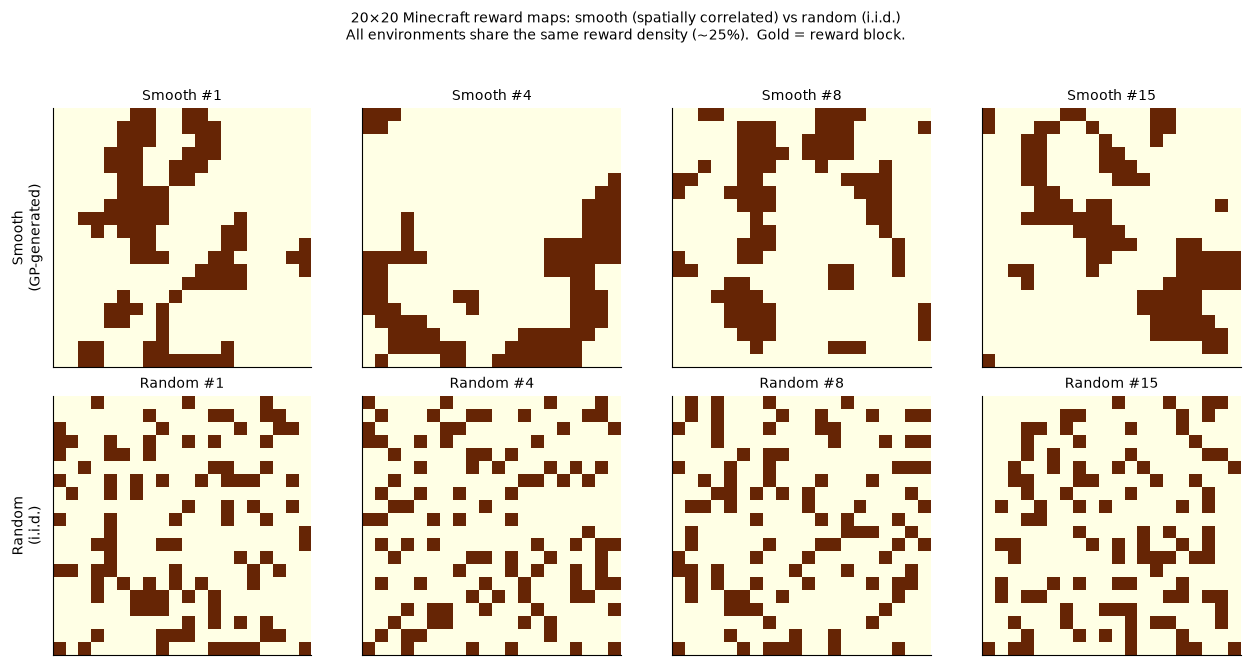

22 smooth environments and 22 random environments in total.
We focus on the solo + smooth condition, where GP generalization is informative for predicting reward clusters.


In [23]:
# A sample of the 20×20 reward maps used in the experiment.
# Each cell is a harvestable melon or pumpkin block: brown = reward (1), cream = no reward (0).
# All environments have the same reward density (~25%), but differ in spatial structure.
import os
import pandas as pd

def load_env_grid(path):
    """Load a 20x20 reward grid from the semicolon-delimited CSV format."""
    return pd.read_csv(path, sep=';', index_col=0).values.astype(float)

env_dir = 'environments'
# Pick 4 illustrative environments of each type
smooth_ids = [1, 4, 8, 15]
random_ids = [1, 4, 8, 15]

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))

for col, idx in enumerate(smooth_ids):
    grid = load_env_grid(os.path.join(env_dir, f'smooth.{idx}.csv'))
    axes[0, col].imshow(grid.T, origin='lower', cmap='YlOrBr', vmin=0, vmax=1, aspect='equal')
    axes[0, col].set_title(f'Smooth #{idx}', fontsize=10)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

for col, idx in enumerate(random_ids):
    grid = load_env_grid(os.path.join(env_dir, f'random.{idx}.csv'))
    axes[1, col].imshow(grid.T, origin='lower', cmap='YlOrBr', vmin=0, vmax=1, aspect='equal')
    axes[1, col].set_title(f'Random #{idx}', fontsize=10)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

axes[0, 0].set_ylabel('Smooth\n(GP-generated)', fontsize=10, labelpad=6)
axes[1, 0].set_ylabel('Random\n(i.i.d.)', fontsize=10, labelpad=6)

fig.suptitle(
    '20×20 Minecraft reward maps: smooth (spatially correlated) vs random (i.i.d.)\n'
    'All environments share the same reward density (~25%).  Gold = reward block.',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

n_smooth = len([f for f in os.listdir(env_dir) if f.startswith('smooth.')])
n_random = len([f for f in os.listdir(env_dir) if f.startswith('random.')])
print(f'{n_smooth} smooth environments and {n_random} random environments in total.')
print('We focus on the solo + smooth condition, where GP generalization is informative for predicting reward clusters.')

Selected: P4  |  session session7.json, round 14
26 block destructions  ·  11 successes  (42% hit rate)
x range: [8.0, 59.0]  z range: [2.0, 41.0]


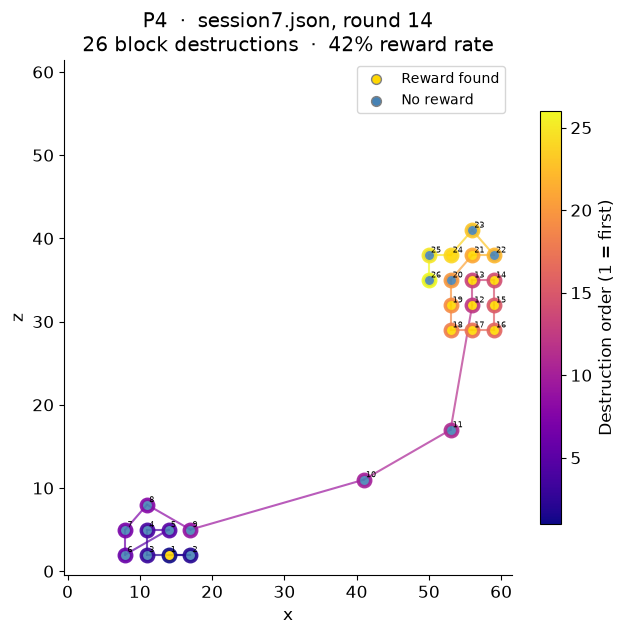


Reading the path:
  Numbers = block destruction order.  Path colour = time (early=purple, late=yellow).
  A GP model predicts: after finding reward (gold), the agent should destroy nearby blocks.
  Jumps to a new area suggest the uncertainty bonus (σ) is pulling the agent away.


In [4]:
PARTICIPANT = 'P4'   # choose an illustrative participant
FIT_SESSION = 'session8.json'  # session used for all model fits (same for all P1–P4)

# Find an illustrative round with diverse spatial coverage and good reward
p_df = df[df['name'] == PARTICIPANT].sort_values(['session', 'round', 'time'])

best_session, best_round, best_rate = None, None, -1
for (sess, rnd), grp in p_df.groupby(['session', 'round']):
    if len(grp) >= 15:
        rate = grp['reward_int'].mean()
        # Prefer rounds with diverse spatial coverage (high x-z variance) AND good reward
        spatial_spread = grp[['x', 'z']].std().sum()
        score = rate + 0.15 * spatial_spread   # small weight on spatial spread
        if score > best_rate:
            best_rate = score
            best_session, best_round = sess, rnd

round_df = p_df[(p_df['session'] == best_session) & (p_df['round'] == best_round)]

print(f'Selected: {PARTICIPANT}  |  session {best_session}, round {best_round}')
print(f'{len(round_df)} block destructions  \u00b7  {round_df["reward_int"].sum()} successes  '
      f'({100*round_df["reward_int"].mean():.0f}% hit rate)')
print(f'x range: [{round_df["x"].min()}, {round_df["x"].max()}]  '
      f'z range: [{round_df["z"].min()}, {round_df["z"].max()}]')

# Plot foraging path with sequential colouring (early \u2192 cool, late \u2192 warm)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
n_destructions = len(round_df)
cmap_seq = plt.cm.plasma

for rank, (_, row) in enumerate(round_df.iterrows()):
    facecolor = 'gold' if row['reward_int'] else 'steelblue'
    edgecolor = cmap_seq(rank / max(n_destructions - 1, 1))
    ax.scatter(row['x'], row['z'], c=facecolor, s=80, zorder=3, alpha=0.9,
               edgecolors=edgecolor, linewidths=2.5)
    ax.text(row['x'] + 0.3, row['z'] + 0.3, str(rank + 1),
            fontsize=6, color='black', zorder=4)

xs = round_df['x'].values
zs = round_df['z'].values
# Colour path segments by time: early = purple, late = yellow
for i in range(len(xs) - 1):
    c = cmap_seq(i / max(n_destructions - 2, 1))
    ax.plot([xs[i], xs[i+1]], [zs[i], zs[i+1]], color=c, linewidth=1.5, alpha=0.7, zorder=1)

ax.scatter([], [], c='gold', s=50, label='Reward found', edgecolors='gray', linewidths=1)
ax.scatter([], [], c='steelblue', s=50, label='No reward', edgecolors='gray', linewidths=1)
sm = plt.cm.ScalarMappable(cmap=cmap_seq, norm=plt.Normalize(1, n_destructions))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Destruction order (1 = first)', shrink=0.8)

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim(-0.5, 61.5); ax.set_ylim(-0.5, 61.5)
ax.set_title(f'{PARTICIPANT}  \u00b7  {best_session}, round {best_round}\n'
             f'{n_destructions} block destructions  \u00b7  {100*round_df["reward_int"].mean():.0f}% reward rate')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print()
print('Reading the path:')
print('  Numbers = block destruction order.  Path colour = time (early=purple, late=yellow).')
print('  A GP model predicts: after finding reward (gold), the agent should destroy nearby blocks.')
print('  Jumps to a new area suggest the uncertainty bonus (\u03c3) is pulling the agent away.')

---
## 2. GP Posterior from Foraging Observations

After each foraging event, the participant has a history of observations: foraged block locations and whether reward was found. We fit a GP to these observations to obtain the **posterior belief** over the whole grid.

This is the same GP toolkit from Day 1, Block 3 (same RBF kernel, same update equations), now applied to real data instead of a simulated agent.

**Coordinate system:** All code in this notebook works directly in the raw block coordinates $x, z \in \{2, 5, 8, \ldots, 59\}$ (20x20 field of pumpkin/watermelon blocks, each placed with a 3 block gap between them). The paper's GP kernel lengthscale is $\ell = \sqrt{48} \approx 6.93$ in this same coordinate system, so fitted $\lambda$ values are directly comparable to the paper.

**GP for binary rewards using the Laplace approximation:** Wu et al. (2025) models binary 0/1 rewards using **GP classification**, by specifying a latent function $z(x) \sim \mathcal{GP}(0, k)$ over the grid, with binary reward observations entering through a Bernoulli likelihood $p(y = 1 \mid z) = \sigma(z)$. The posterior $p(z \mid \mathcal{D}_t)$ is non-Gaussian, but we can use the **Laplace approximation** (Rasmussen & Williams 2006, Algorithm 3.2), we are able to describe the latent posterior mean $\mu_t(x)$ and std $\sigma_t(x)$ at each block.

The latent $z$ lives on the real line: $z \gg 0$ means reward is expected, $z \ll 0$ means reward is unlikely, and $z \approx 0$ is uncertain. The **G feature** (Section 3) is simply this latent mean $\mu_t(x)$, used directly in the softmax GLM.

The four panels below show how the Laplace posterior evolves over the selected round, with the latent $z$ displayed using a diverging colormap (red = reward expected, blue = no reward, white = prior/uncertain).

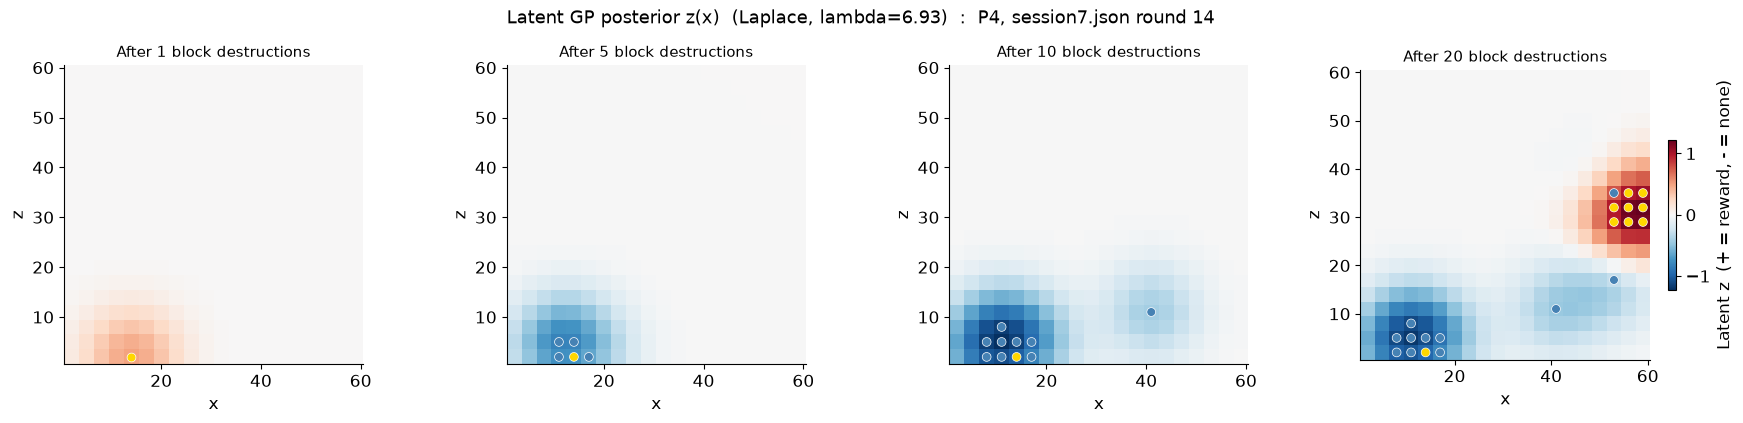

Interpretation:
  Gold dots = found reward; blue dots = no reward.
  Red = GP predicts reward likely (z > 0).  Blue = reward unlikely (z < 0).  White = uncertain (z ~ 0).
  After step 5: beliefs (about no reward) begin to cluster around early reward sites.
  After step 20: a new patch is found and the posterior shows clear spatial structure around the patch.


In [5]:
def plot_gp_posterior_on_grid(X_obs, y_obs, X_all, lengthscale, title='GP posterior', ax=None):
    """Visualise latent GP posterior (Laplace) on the 20x20 block grid."""
    if len(X_obs) > 0:
        mu, std = gp_laplace_posterior(X_obs, y_obs, X_all, lengthscale=lengthscale)
    else:
        mu, std = np.zeros(N_BLOCKS), np.ones(N_BLOCKS)

    mu_grid = mu.reshape(N_GRID, N_GRID)
    abs_max = max(float(np.abs(mu).max()), 1.0)  # symmetric range so white = prior

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    im = ax.imshow(mu_grid.T, origin='lower', aspect='equal',
                   cmap='RdBu_r', vmin=-abs_max, vmax=abs_max,
                   extent=GRID_EXTENT)
    if len(X_obs) > 0:
        colors = ['gold' if y else 'steelblue' for y in y_obs]
        ax.scatter(X_obs[:, 0], X_obs[:, 1], c=colors, s=40, zorder=3,
                   edgecolors='white', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('z')
    return im, mu, std


# Evolving latent GP posterior at steps 1, 5, 10, 20 of the selected round
decisions = list(iter_decisions(round_df))

LAMBDA = np.sqrt(48)   # paper lengthscale in raw coordinates; we fit this in Part 4
steps_to_show = [1, 5, 10, 20]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, step in zip(axes, steps_to_show):
    if step >= len(decisions):
        step = len(decisions) - 1
    X_obs, y_obs, _ = decisions[step]
    im, _, _ = plot_gp_posterior_on_grid(X_obs, y_obs, X_ALL, LAMBDA,
                                          title=f'After {step} block destructions', ax=ax)

plt.colorbar(im, ax=axes[-1], label='Latent z  (+ = reward, - = none)', shrink=.5)
fig.suptitle(f'Latent GP posterior z(x)  (Laplace, lambda={LAMBDA:.2f})  :  {PARTICIPANT}, {best_session} round {best_round}',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Gold dots = found reward; blue dots = no reward.')
print('  Red = GP predicts reward likely (z > 0).  Blue = reward unlikely (z < 0).  White = uncertain (z ~ 0).')
print('  After step 5: beliefs (about no reward) begin to cluster around early reward sites.')
print('  After step 20: a new patch is found and the posterior shows clear spatial structure around the patch.')

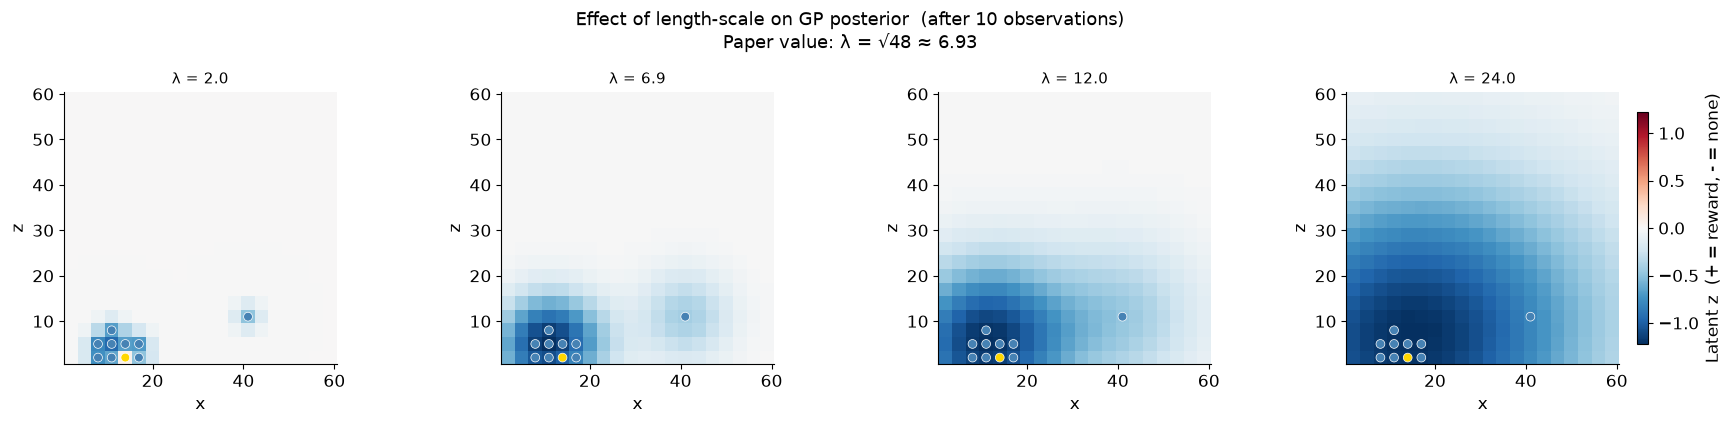

Small λ: beliefs stay local to observed blocks.
λ = √48 ≈ 6.93: paper value; moderate generalization across 2 to 3 blocks.
Large λ: beliefs propagate far across the grid.


In [6]:
# How does the length-scale shape the posterior?
X_obs, y_obs, _ = decisions[10]
lambdas = [2.0, np.sqrt(48), 12.0, 24.0]   # narrow → paper value → broad → very broad

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, lam in zip(axes, lambdas):
    im, _, _ = plot_gp_posterior_on_grid(X_obs, y_obs, X_ALL, lam,
                                          title=f'λ = {lam:.1f}', ax=ax)

plt.colorbar(im, ax=axes[-1], label='Latent z  (+ = reward, - = none)', shrink=0.85)
fig.suptitle(f'Effect of length-scale on GP posterior  (after 10 observations)\n'
             f'Paper value: λ = √48 ≈ {np.sqrt(48):.2f}', fontsize=13)
plt.tight_layout()
plt.show()
print('Small λ: beliefs stay local to observed blocks.')
print(f'λ = √48 ≈ {np.sqrt(48):.2f}: paper value; moderate generalization across 2 to 3 blocks.')
print('Large λ: beliefs propagate far across the grid.')

---
### Does the GP actually guide choices?

Before fitting any model, we can test whether the GP posterior already predicts choices non-parametrically. At each decision step, we rank all **undestroyed** blocks by their GP posterior mean and record where the participant's **actual choice** falls in that ranking.

- Rank = 1.0 means the chosen block had the highest GP mean of all available options.
- Rank = 0.5 is random (chance level).
- Consistently above 0.5 → participants prefer blocks where the GP predicts reward.

This analysis does not estimate model weights at all. Instead, it is simple test of whether the GP posterior correlates with choices, independent of locality.

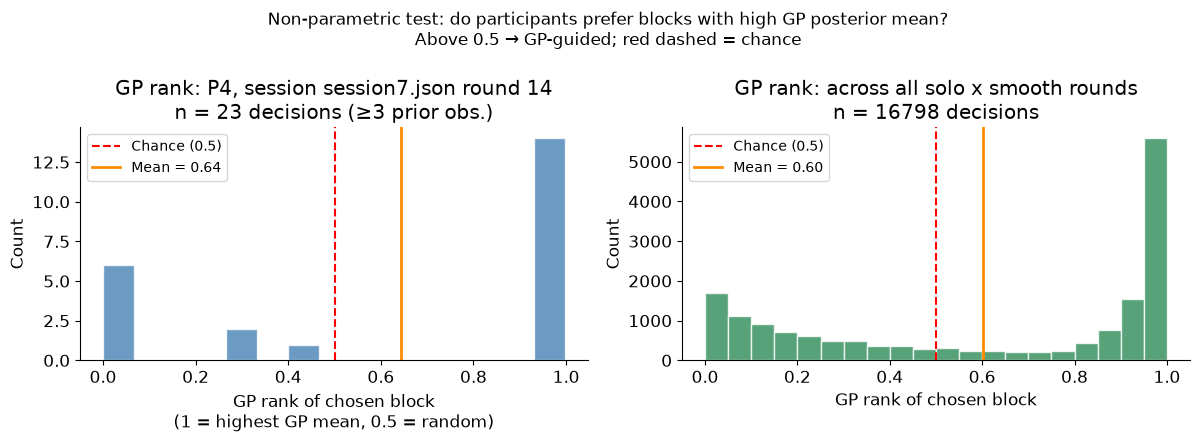

Selected participant & round:  mean GP rank = 0.644  (p-value vs 0.5: 0.61 of choices above median)
Across all data: mean GP rank = 0.601

Interpretation: even before fitting any model weights, the GP posterior predicts the blocks participants choose (above chance)
This motivates the GL model: we now want to QUANTIFY how much GP prediction and locality each contribute.


In [7]:
from scipy.spatial.distance import cdist as _cdist

def gp_rank_of_choice(decisions, X_all, lengthscale):
    """For each decision (with ≥3 observations), return the percentile rank of the
    chosen block among all unvisited blocks by GP posterior mean.
    Rank=1.0 = best possible choice; 0.5 = random; 0.0 = worst."""
    ranks = []
    for X_obs, y_obs, next_idx in decisions:
        if len(X_obs) < 3:
            continue
        mu, std = gp_laplace_posterior(X_obs, y_obs, X_all, lengthscale=lengthscale)
        visited_mask = _cdist(X_all, X_obs).min(axis=1) < 1.0
        mu_unvisited = mu[~visited_mask]
        if len(mu_unvisited) == 0:
            continue
        chosen_mu = mu[next_idx]
        rank = (mu_unvisited < chosen_mu).mean()   # fraction of unvisited blocks with lower GP mean
        ranks.append(rank)
    return np.array(ranks)

# Compute GP-rank for the selected round
all_decisions = list(iter_decisions(round_df))
ranks_round = gp_rank_of_choice(all_decisions, X_ALL, lengthscale=np.sqrt(48))

# Compute GP-rank across all rounds (df is already filtered to solo+smooth by tidy())
ranks_all = []
round_count = 0
for (sess, rnd), grp in df.groupby(['session', 'round']):
    decs = list(iter_decisions(grp.sort_values('time')))
    r = gp_rank_of_choice(decs, X_ALL, lengthscale=np.sqrt(48))
    ranks_all.extend(r.tolist())
    round_count += 1
ranks_all = np.array(ranks_all)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: histogram for selected round
ax = axes[0]
ax.hist(ranks_round, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Chance (0.5)')
ax.axvline(ranks_round.mean(), color='darkorange', linestyle='-', linewidth=2,
           label=f'Mean = {ranks_round.mean():.2f}')
ax.set_xlabel('GP rank of chosen block\n(1 = highest GP mean, 0.5 = random)')
ax.set_ylabel('Count')
ax.set_title(f'GP rank: {PARTICIPANT}, session {best_session} round {best_round}\n'
             f'n = {len(ranks_round)} decisions (≥3 prior obs.)')
ax.legend(fontsize=10)

# Right: across-rounds distribution
ax = axes[1]
ax.hist(ranks_all, bins=20, color='seagreen', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Chance (0.5)')
ax.axvline(ranks_all.mean(), color='darkorange', linestyle='-', linewidth=2,
           label=f'Mean = {ranks_all.mean():.2f}')
ax.set_xlabel('GP rank of chosen block')
ax.set_ylabel('Count')
ax.set_title(f'GP rank: across all solo x smooth rounds\n'
             f'n = {len(ranks_all)} decisions')
ax.legend(fontsize=10)

plt.suptitle('Non-parametric test: do participants prefer blocks with high GP posterior mean?\n'
             'Above 0.5 → GP-guided; red dashed = chance', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Selected participant & round:  mean GP rank = {ranks_round.mean():.3f}  (p-value vs 0.5: '
      f'{float(np.mean(ranks_round > 0.5)):.2f} of choices above median)')
print(f'Across all data: mean GP rank = {ranks_all.mean():.3f}')
print()
print('Interpretation: even before fitting any model weights, the GP posterior predicts the blocks participants choose (above chance)')
print('This motivates the GL model: we now want to QUANTIFY how much GP prediction and locality each contribute.')

---
## 3. The Softmax GLM Choice Model

### Canonical form (Wu et al. 2025)

The paper models each foraging choice as a **softmax General Linear Model (GLM)**:

$$P(\text{Choice}_{k+1}) \propto \exp\!\bigl(\mathbf{f}_k \cdot \mathbf{w}\bigr)$$

where $\mathbf{f}_k$ is a vector of *block features* (evaluated when the $k$-th block was destroyed) and $\mathbf{w}$ is a weight vector estimated by maximum likelihood. Each feature gets its own weight, and hypotheses about what drives behaviour are tested by adding or removing features.

### Why not just use UCB+softmax from Day 1, Block 3?

In Block 3, the agent makes choices with probability $P(x) \propto \exp\!\bigl((\mu_k(x) + \beta\,\sigma_k(x))\,/\,\tau\bigr)$. This collapses GP mean, uncertainty, and temperature into a single expression, making it more complicated to add an independent locality term or to compare how much each features matters on the same scale. The GLM resolves this, by allowing each feature to compete transparently with its own estimated weight.

### Feature letter codes

| Letter | Feature | Formula | Range | Interpretation |
|:---:|---|---|---|---|
| **G** | Reward Prediction | $\mu_t(x)$ | $(-\infty, +\infty)$ | Latent GP signal; positive = reward expected, negative = absent |
| **L** | Locality | $-\|x - x_\text{curr}\|$ | $(-\infty, 0]$ | Proximity preference: nearby blocks are cheaper to reach |
| **U** | Uncertainty | $\sigma_t(x)$ | $[0,\infty)$ | GP posterior std; explicit exploration bonus (Extension B only) |

**G is the 'Reward Prediction' feature from Wu et al. (2025).** It is the latent posterior mean $\mu_k(x)$ from the Laplace approximation of the GP classification model. Because $\mu_k(x)$ is a real-valued variable, it naturally encodes both signal direction and magnitude: large positive values predict a reward, large negative values predict no reward, and values near zero are very uncertainty. The weight $w_G$ scales this signal in the softmax.

### Model variants

Wu et al. (2025) **fixed $\lambda = \sqrt{48} \approx 6.93$** (i.e., the ground-truth lengthscale of the smooth reward environment) rather than estimating it. This means each model uses a single coefficient per feature, without any other free parameters:

| Model | Formula | Parameters | k | Note |
|:---:|---|---|:---:|---|
| **L** | $\exp(w_L\,\text{loc})$ | $w_L$ | 1 | |
| **G** | $\exp(w_G\,\mu_t)$ | $w_G$ | 1 | $\lambda = \sqrt{48}$ fixed |
| **GL** | $\exp(w_G\,\mu_t + w_L\,\text{loc})$ | $w_G,\,w_L$ | 2 | $\lambda = \sqrt{48}$ fixed |

**GL** (k=2) is simplified version of the model from Wu et al. (2025). The fixed-$\lambda$ assumption is tested separately in Section 6 (lengthscale sensitivity), where we compare GL-fixed to a version with $\lambda$ freely estimated (k=3). This allows us to estimate whether participants' effective generalization radius differs from the environment.


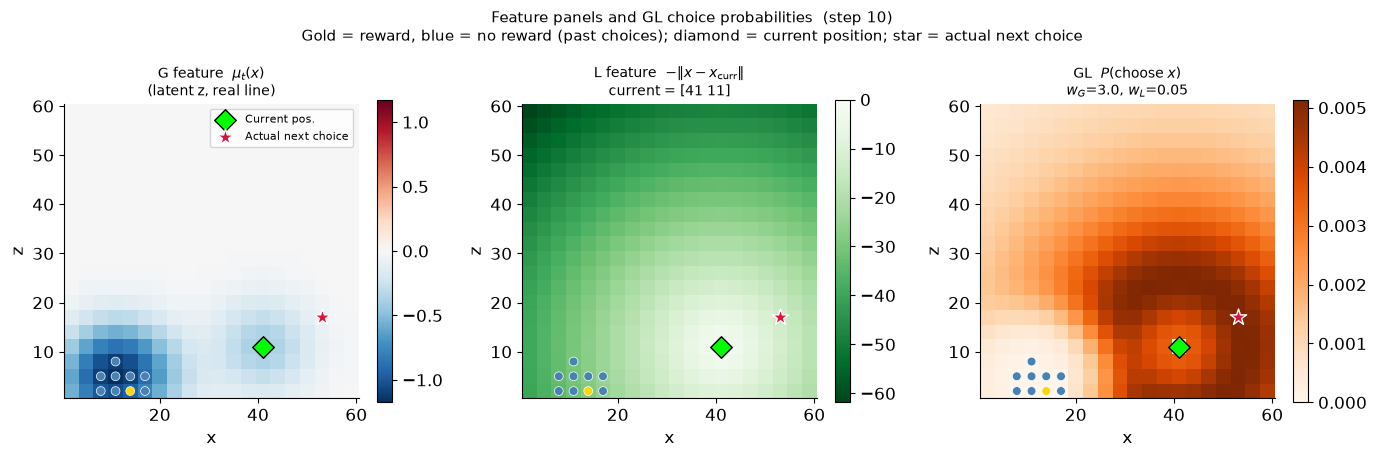

In [8]:
# Visualise features and GL choice probabilities at step 10
step = 10
X_obs, y_obs, next_idx = decisions[step]

# Use some handpicked values for visualization purposes
LAMBDA_DEMO  = np.sqrt(48)   # paper lengthscale in raw coordinates
W_G_DEMO     = 3.0           # weight on G (latent z)
W_L_DEMO     = 0.05          # weight on L (locality; small because raw distances ∈ [0, ~81])

# Compute Laplace classification posterior: latent z mean and std
mu, std = gp_laplace_posterior(X_obs, y_obs, X_ALL, lengthscale=LAMBDA_DEMO)

# Compute features
x_current = X_obs[-1]
loc = locality_feature(X_ALL, x_current)

# GL choice probabilities (G = mu, L = loc)
from models import _visited_mask
visited = _visited_mask(X_ALL, X_obs)
probs = glm_choice_probs(mu, std, loc, W_G_DEMO, 0.0, W_L_DEMO, visited)

abs_max = max(float(np.abs(mu).max()), 1.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

panels = [
    (mu,   r'G feature  $\mu_t(x)$' + '\n(latent z, real line)',
     'RdBu_r', dict(vmin=-abs_max, vmax=abs_max)),
    (loc,  r'L feature  $-\|x - x_\mathrm{curr}\|$' + f'\ncurrent = {x_current.round(0).astype(int)}',
     'Greens_r', {}),
    (probs, r'GL  $P(\mathrm{choose}\;x)$' + '\n$w_G$={:.1f}, $w_L$={:.2f}'.format(W_G_DEMO, W_L_DEMO),
     'Oranges', {}),
]

for ax, (values, title, cmap, kwargs) in zip(axes, panels):
    im = ax.imshow(values.reshape(N_GRID, N_GRID).T, origin='lower', aspect='equal',
                   cmap=cmap, extent=GRID_EXTENT, **kwargs)
    c_obs = ['gold' if y else 'steelblue' for y in y_obs]
    ax.scatter(x_current[0], x_current[1], c='lime', s=120, marker='D', zorder=5,
               edgecolors='black', linewidth=1, label='Current pos.')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c=c_obs, s=40, zorder=3,
               edgecolors='white', linewidth=0.5)
    ax.scatter(X_ALL[next_idx, 0], X_ALL[next_idx, 1], c='crimson', s=150,
               marker='*', zorder=6, edgecolors='white', label='Actual next choice')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('z')
    plt.colorbar(im, ax=ax, shrink=0.85)

axes[0].legend(fontsize=8, loc='best')
fig.suptitle(
    f'Feature panels and GL choice probabilities  (step {step})\n'
    'Gold = reward, blue = no reward (past choices); diamond = current position; star = actual next choice',
    fontsize=11
)
plt.tight_layout()
plt.show()


<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/var/folders/gs/3cz278j11vdf2ly8x_cqj__h0000gn/T/ipykernel_65916/506948998.py:24: SyntaxWarning: invalid escape sequence '\l'
  (probs_G,  r'$\mathbf{G}$: Latent z only (k=1)' + f'\n$\lambda$={LAMBDA_DEMO:.2f} fixed, $w_G$={W_G}',                     'Blues'),
/var/folders/gs/3cz278j11vdf2ly8x_cqj__h0000gn/T/ipykernel_65916/506948998.py:25: SyntaxWarning: invalid escape sequence '\l'
  (probs_GL, r'$\mathbf{GL}$: Latent z + Locality (k=2)' + f'\n$\lambda$={LAMBDA_DEMO:.2f} fixed, $w_G$={W_G}, $w_L$={W_L}', 'Oranges'),


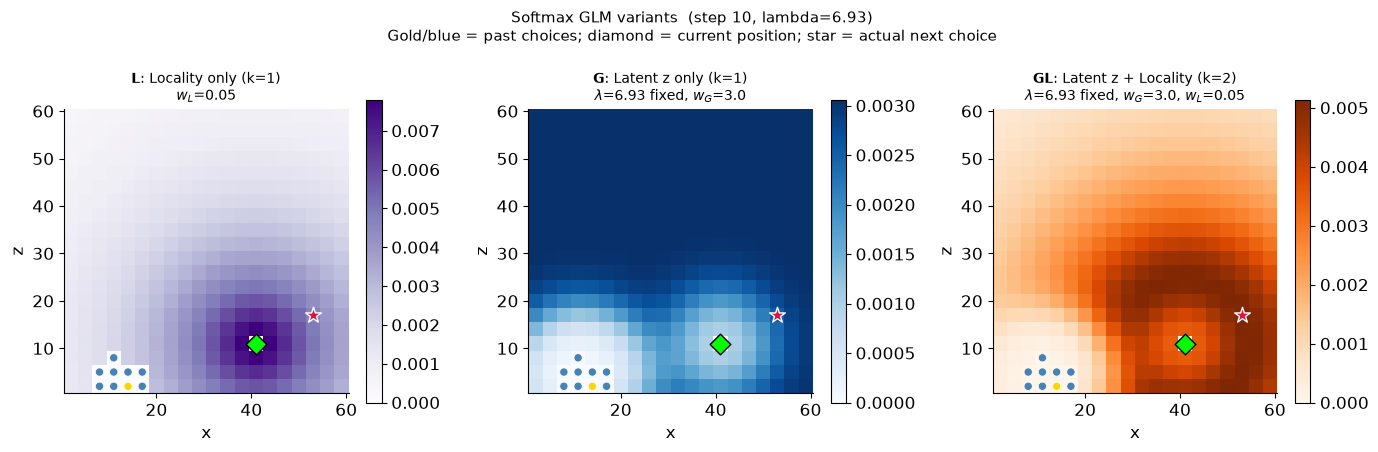

In [9]:
# Side-by-side: compare three softmax GLM variants at step 10
step = 10
X_obs, y_obs, next_idx = decisions[step]

# Parameter values
LAMBDA_DEMO = np.sqrt(48)   # paper lengthscale in raw coordinates
W_G = 3.0     # weight on G (latent z from Laplace GP)
W_L = 0.05    # weight on L (locality; small because raw distances ∈ [0, ~81])

mu, std = gp_laplace_posterior(X_obs, y_obs, X_ALL, lengthscale=LAMBDA_DEMO)
x_current  = X_obs[-1]
loc        = locality_feature(X_ALL, x_current)
from models import _visited_mask
visited    = _visited_mask(X_ALL, X_obs)

# Three variants: L, G, GL
probs_L  = glm_choice_probs(mu, std, loc, 0.0, 0.0, W_L,  visited)   # L only
probs_G  = glm_choice_probs(mu, std, loc, W_G,  0.0, 0.0, visited)   # G only
probs_GL = glm_choice_probs(mu, std, loc, W_G,  0.0, W_L,  visited)  # GL

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
panels = [
    (probs_L,  r'$\mathbf{L}$: Locality only (k=1)' + f'\n$w_L$={W_L}',                                                  'Purples'),
    (probs_G,  r'$\mathbf{G}$: Latent z only (k=1)' + f'\n$\lambda$={LAMBDA_DEMO:.2f} fixed, $w_G$={W_G}',                     'Blues'),
    (probs_GL, r'$\mathbf{GL}$: Latent z + Locality (k=2)' + f'\n$\lambda$={LAMBDA_DEMO:.2f} fixed, $w_G$={W_G}, $w_L$={W_L}', 'Oranges'),
]

for ax, (values, title, cmap) in zip(axes, panels):
    im = ax.imshow(values.reshape(N_GRID, N_GRID).T, origin='lower', aspect='equal',
                   cmap=cmap, extent=GRID_EXTENT)
    colors_obs = ['gold' if y else 'steelblue' for y in y_obs]
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c=colors_obs, s=35, zorder=3,
               edgecolors='white', linewidth=0.5)
    ax.scatter(x_current[0], x_current[1], c='lime', s=110, marker='D', zorder=5,
               edgecolors='black', linewidth=1)
    ax.scatter(X_ALL[next_idx, 0], X_ALL[next_idx, 1], c='crimson', s=140,
               marker='*', zorder=6, edgecolors='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('z')
    plt.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle(
    f'Softmax GLM variants  (step {step}, lambda={LAMBDA_DEMO:.2f})\n'
    'Gold/blue = past choices; diamond = current position; star = actual next choice',
    fontsize=11
)
plt.tight_layout()
plt.show()

---
### Log-Likelihood

To fit the model we need a **log-likelihood**: the probability the model assigns to the sequence of observed choices.

At each decision step $k$, the participant has destroyed blocks $\{x_1, \ldots, x_{k-1}\}$ with outcomes $\{y_1, \ldots, y_{k-1}\}$. We:
1. Run the Laplace approximation on the GP classification model to obtain the latent posterior $\mu_k(x),\, \sigma_k(x)$ at all **undestroyed** blocks
2. Compute locality $\text{loc}_k(x) = -\|x - x_{k-1}\|$ from the last destroyed block. *(This is an approximation, since participants move continuously. As in the paper, we treat the most recently destroyed block as the current position.)*
3. Compute the softmax GLM choice probabilities:
$$P_t(x) \propto \exp\!\bigl(w_G\cdot \mu_k(x) + w_L\cdot \text{loc}_k(x)\bigr)$$
where $\mu_k(x)$ is the Laplace posterior mean (i.e., latent GP signal on the real line)
4. Record $\log P_k(x_k)$ for the block actually chosen

**Why does the sum start at step 2?** The GP posterior requires at least one observation to condition on. The very first choice in a round has no history, so the GP has nothing to update from and we cannot compute a meaningful choice probability. We therefore start predictions at step 2, using the outcome of step 1 as the first observation. This is why the log-likelihood sums over $k-1$ decisions rather than $k$.

Additionally, we always condition on the *true* past choices, not on the model's predicted choices. This keeps each step's GP posterior and locality signal fixed to what actually happened. Summing across all decisions in a round gives the round log-likelihood:

$$\mathcal{L}(w_G, w_L) = \sum_{k=2}^{\max k} \log P_t(x_k \mid x_1, y_1, \ldots, x_{k-1}, y_{k-1};\, w_G, w_L)$$


In [10]:
# Compute GL model log-likelihood for one decision and a full round

# Single decision at step 10
ll_single = decision_loglik_glm(
    X_ALL, X_obs, y_obs, next_idx,
    lengthscale=LAMBDA_DEMO,
    w_mean=W_G_DEMO, w_ucb=0.0, w_local=W_L_DEMO,
)
print(f'Decision at step {step}:')
print(f'  Block {next_idx} chosen  (x={X_ALL[next_idx,0]:.1f}, z={X_ALL[next_idx,1]:.1f})')
print(f'  Log-likelihood: {ll_single:.3f}  (probability: {np.exp(ll_single)*100:.1f}%)')
print()

# Full round log-likelihood (skip first step with empty history)
all_decisions = [(X, y, idx) for X, y, idx in decisions if len(X) > 0]
ll_round = round_loglik_glm(
    all_decisions, X_ALL,
    LAMBDA_DEMO, W_G_DEMO, 0.0, W_L_DEMO,
)
n_dec = len(all_decisions)
print(f'Full round log-likelihood ({n_dec} decisions): {ll_round:.2f}')
print(f'Average per decision: {ll_round/n_dec:.3f}')
print()

# Baseline: uniform choice over undestroyed blocks
ll_uniform = sum(-np.log(N_BLOCKS - t) for t in range(1, n_dec + 1))
print(f'Uniform baseline log-likelihood: {ll_uniform:.2f}')
print(f'Improvement over uniform: {ll_round - ll_uniform:+.2f} nats  '
      f'({(ll_round - ll_uniform)/np.log(2):.1f} bits); positive means better than chance')

---
## 4. Maximum Likelihood Estimation

### Why MLE instead of Bayesian inference?

Wu et al. (2025) used a Bayesian hierarchical model with STAN to simultaneously estimate participant-level and group-level parameters. This produces full posterior distributions and propagates uncertainty correctly across participants, but requires writing probabilistic programs, tuning samplers, and waiting days for convergence.

**Today we use MLE**: we directly maximise $\mathcal{L}(w_G, w_L)$ using `scipy.optimize.minimize` with the Nelder-Mead simplex algorithm. For this tutorial, MLE is a practical choice: it is pure Python via `scipy.optimize`, runs in seconds per participant, and the objective is exactly the log-likelihood we just defined. With 2 free parameters and well-separated features, the likelihood surface is well-behaved and Nelder-Mead converges reliably.

The trade-off: MLE gives point estimates, not posteriors. For the research paper, Bayesian methods provide the most robustness. For first learning how to do this kind of modeling, MLE is completely sufficient.

### The optimization problem

Following Wu et al. (2025), we **fix $\lambda = \sqrt{48} \approx 6.93$** (the ground-truth lengthscale of the smooth environment) and estimate only the GLM weights. This keeps the GP component faithful to the paper and reduces the parameter count so that model comparison is interpretable:

$$\hat{w}_G,\, \hat{w}_L = \arg\min_{(w_G,\, w_L)} \left[-\mathcal{L}(w_G, w_L \mid \lambda = \sqrt{48})\right]$$

**Primary model: GL** (GP-mean + Locality, k=2)
- $w_G$: weight on GP posterior mean (feature G); how much reward structure guides choices
- $w_L$: weight on locality (feature L); how much proximity matters

**Ablations:** we also fit **G** (k=1, no locality) and **L** (k=1, no GP) to identify which features contribute. Full BIC comparison in Section 6.

We use **random restarts** (`n_restarts=1` to start, though 3-5 give more stable results) to avoid local optima.

**Extension (Section 6):** we also compare a version of GL with $\lambda$ freely estimated (k=3). This tests whether participants' effective generalization radius matches the environment and connects to the under-generalization finding in Wu et al. (2018).


In [11]:
%%time
# Fit the GL model (GP-mean + Locality, k=2: w_G, w_L; lambda fixed at sqrt(48)).
# Wu et al. (2025) fixed lambda to the known environment lengthscale rather than estimating it.
# Fits only the 4 solo+smooth rounds from FIT_SESSION (same data used for the pre-computed fits).
# n_restarts=1 for speed; try 3 or 5 for more stable estimates.
LAMBDA_PAPER = np.sqrt(48)   # fixed at environment ground truth
result_gl = fit_participant_glm_no_ucb(
    df[df['session'] == FIT_SESSION], PARTICIPANT, X_all=X_ALL,
    n_restarts=1, max_decisions=100, seed=2026,
    fixed_lengthscale=LAMBDA_PAPER,
)
print(f'GL model (GP-mean + Locality, k=2, lambda fixed)  [{PARTICIPANT}, {FIT_SESSION}]:')
print(f'  lambda = {result_gl["lengthscale"]:.3f}   (fixed at sqrt(48) \u2248 {LAMBDA_PAPER:.2f}: groundtruth lengthscale)')
print(f'  w_G    = {result_gl["w_mean"]:.3f}   (weight on GP latent mean: reward structure exploitation)')
print(f'  w_L    = {result_gl["w_local"]:.4f}   (weight on locality: proximity preference)')
print(f'  negloglik = {result_gl["negloglik"]:.2f}  (n_steps = {result_gl["n_steps"]})')
print()
print('Interpretation:')
print('  w_G > 0: participant uses GP mean to guide choices toward expected rewards.')
print('  w_L > 0: strong proximity preference (nearby blocks strongly favoured).')

GL model (GP-mean + Locality, k=2, lambda fixed)  [P4, session8.json]:
  lambda = 6.928   (fixed at sqrt(48) ≈ 6.93: groundtruth lengthscale)
  w_G    = 4.314   (weight on GP latent mean: reward structure exploitation)
  w_L    = 0.7968   (weight on locality: proximity preference)
  negloglik = 259.51  (n_steps = 134)

Interpretation:
  w_G > 0: participant uses GP mean to guide choices toward expected rewards.
  w_L > 0: strong proximity preference (nearby blocks strongly favoured).
CPU times: user 5.42 s, sys: 3.12 s, total: 8.54 s
Wall time: 4.74 s


In [12]:
%%time
# Fit the two ablation variants to the illustrative participant for comparison.
# G: lambda fixed at sqrt(48), only w_G estimated (k=1)
# L: only w_L estimated (k=1), no GP
LAMBDA_PAPER = np.sqrt(48)
df_sess = df[df['session'] == FIT_SESSION]   # same 4 rounds as the GL fit above
result_g = fit_participant_gp_mean_only(
    df_sess, PARTICIPANT, X_all=X_ALL,
    n_restarts=1, max_decisions=100, seed=2026,
    fixed_lengthscale=LAMBDA_PAPER,
)
result_l = fit_participant_locality_only(
    df_sess, PARTICIPANT, X_all=X_ALL,
    n_restarts=3, max_decisions=100, seed=2026,
)

print(f'G model (GP-mean only, k=1, lambda fixed)  [{PARTICIPANT}]:')
print(f'  lambda = {result_g["lengthscale"]:.3f}   (fixed)')
print(f'  w_G    = {result_g["w_mean"]:.3f}')
print(f'  negloglik = {result_g["negloglik"]:.2f}')
print()
print(f'L model (Locality-only, k=1)  [{PARTICIPANT}]:')
print(f'  w_L    = {result_l["w_local"]:.4f}')
print(f'  negloglik = {result_l["negloglik"]:.2f}')
print()

# Quick BIC preview (full analysis including lengthscale sensitivity in Section 6)
# All three models have k=1 or k=2; lambda is not counted for GL and G since it is fixed.
n_steps = result_gl['n_steps']
bic_gl = compute_bic_glm(result_gl['negloglik'], n_params=2, n_steps=n_steps)
bic_g  = compute_bic_glm(result_g['negloglik'],  n_params=1, n_steps=n_steps)
bic_l  = compute_bic_glm(result_l['negloglik'],  n_params=1, n_steps=n_steps)
best_bic = min(bic_gl, bic_g, bic_l)

print(f'{"Model":<8}  {"k":>3}  {"BIC":>8}  {"\u0394BIC vs L":>10}')
print('-' * 36)
for label, bic, k in [('GL', bic_gl, 2), ('G', bic_g, 1), ('L', bic_l, 1)]:
    flag = '  <- best' if bic == best_bic else ''
    delta = f'{bic - bic_l:+.1f}' if label != 'L' else '    ---'
    print(f'{label:<8}  {k:>3}  {bic:>8.1f}  {delta:>10}{flag}')
print()
print('(Full 3-way BIC analysis in Section 6 uses GL as the reference.)')

G model (GP-mean only, k=1, lambda fixed)  [P4]:
  lambda = 6.928   (fixed)
  w_G    = 4.893
  negloglik = 655.49

L model (Locality-only, k=1)  [P4]:
  w_L    = 0.7479
  negloglik = 301.99

Model       k       BIC   ΔBIC vs L
------------------------------------
GL          2     528.8       -80.1  <- best
G           1    1315.9      +707.0
L           1     608.9         ---

(Full 3-way BIC analysis in Section 6 uses GL as the reference.)
CPU times: user 3.2 s, sys: 1.36 s, total: 4.56 s
Wall time: 2.91 s


---
## 5. All Participant in session

Pre-computed fits for all four participants can be loaded from disk when available. If you make any changes, you can 1) remove or rename 'data/precomputed_fits_track2.json' and then 2) uncomment the commented out code block below to rerun.

**Reminder:** P1–P4 identify player *slots* within a session, not unique individuals across the dataset. Each `(name, session)` pair identifies one person; the fits below pool across all sessions for each slot.

**To compute your own fits:** uncomment and run the fitting loop below (~30-60 s per slot with `n_restarts=1`). Fits use the full solo+smooth dataset.

### What to look for

- **w_G**: positive for all? Positive $w_G$ means the GP posterior mean guides choices toward expected rewards.
- **w_L**: Wu et al. (2025) found locality was a predictive feature of choices. Is it consistently positive?
- **w_L vs w_G**: Wu et al. (2025) found locality dominated, but both features contributed. Does that pattern hold here?
- **Section 6 BIC**: does **GL** outperform both **G** and **L**? If so, participants use both reward structure and proximity. If **G** ties or beats **GL**, the locality term does not add predictive power beyond reward structure alone.



In [24]:
import json, os

# ── Load pre-computed fits (instructor-generated before the session) ──────────
# Remove or rename the file below to force refitting.
PRECOMPUTED_PATH = 'data/precomputed_fits_track2.json'

if os.path.exists(PRECOMPUTED_PATH):
    with open(PRECOMPUTED_PATH) as f:
        _saved = json.load(f)
    gl_fits  = _saved.get('gl',  {})   # GL: GP-mean + Locality (k=2, lambda fixed = sqrt(48))
    g_fits   = _saved.get('g',   {})   # G:  GP-mean only        (k=1, lambda fixed = sqrt(48))
    l_fits   = _saved.get('l',   {})   # L:  Locality-only       (k=1)
    glu_fits = _saved.get('glu', {})   # GLU: + explicit uncertainty (k=3, Extension B)
    print(f'Loaded pre-computed fits from {PRECOMPUTED_PATH}')
    print(f'(All fits use FIT_SESSION = {FIT_SESSION}, 4 solo+smooth rounds per participant)')
else:
    gl_fits  = {'P1': None, 'P2': None, 'P3': None, PARTICIPANT: result_gl}
    g_fits   = {'P1': None, 'P2': None, 'P3': None, PARTICIPANT: result_g}
    l_fits   = {'P1': None, 'P2': None, 'P3': None, PARTICIPANT: result_l}
    glu_fits = {'P1': None, 'P2': None, 'P3': None, PARTICIPANT: None}
    print(f'{PRECOMPUTED_PATH} not found; showing {PARTICIPANT} only (from Section 4).')
    print('Uncomment the fitting loop below and run to fit all participants.')

# # ── Fitting loop (uncomment to refit; ~30-60 s per iteration with n_restarts=1) ───
# # Uses FIT_SESSION only (4 solo+smooth rounds per participant slot).
# LAMBDA_PAPER = np.sqrt(48)
# df_sess = df[df['session'] == FIT_SESSION]
# for name in ['P1', 'P2', 'P3', 'P4']:
#     gl_fits[name] = fit_participant_glm_no_ucb(
#         df_sess, name, X_all=X_ALL, n_restarts=1,
#         max_decisions=100, seed=2026,
#         fixed_lengthscale=LAMBDA_PAPER)              # k=2: w_G + w_L
#     g_fits[name]  = fit_participant_gp_mean_only(
#         df_sess, name, X_all=X_ALL, n_restarts=1,
#         max_decisions=100, seed=2026,
#         fixed_lengthscale=LAMBDA_PAPER)              # k=1: w_G only
#     l_fits[name]  = fit_participant_locality_only(
#         df_sess, name, X_all=X_ALL, n_restarts=1,
#         max_decisions=100, seed=2026)                 # k=1: w_L only
#     r = gl_fits[name]
#     print(f"{name}: w_G={r['w_mean']:.3f}  w_L={r['w_local']:.4f}  "
#           f"n_steps={r['n_steps']}  negloglik={r['negloglik']:.1f}")
#
# with open(PRECOMPUTED_PATH, 'w') as f:
#     json.dump({'gl': gl_fits, 'g': g_fits, 'l': l_fits, 'glu': glu_fits}, f, indent=2)
# print(f'\nSaved to {PRECOMPUTED_PATH}')

# ── Display GL model results ──────────────────────────────────────────────────
participants = [p for p, v in gl_fits.items() if v is not None]
if not participants:
    print('No results yet. Run the fitting loop above.')
else:
    print(f'\nGL model (k=2, lambda=sqrt(48) fixed):')
    print(f'  {"Participant":>10}  {"w_G":>6}  {"w_L":>7}  {"n_steps":>7}  {"negloglik":>10}')
    print('-' * 50)
    for p in participants:
        f_ = gl_fits[p]
        print(f'  {p:>10}  {f_["w_mean"]:>6.3f}  {f_["w_local"]:>7.4f}  '
              f'{f_["n_steps"]:>7}  {f_["negloglik"]:>10.1f}')

Loaded pre-computed fits from data/precomputed_fits_track2.json
(All fits use FIT_SESSION = session8.json, 4 solo+smooth rounds per participant)

GL model (k=2, lambda=sqrt(48) fixed):
  Participant     w_G      w_L  n_steps   negloglik
--------------------------------------------------
          P1   2.989   0.8912      151       297.8
          P2   1.333   1.3250      129       209.5
          P3   3.577   0.7617      131       280.9
          P4   4.314   0.7968      134       259.5


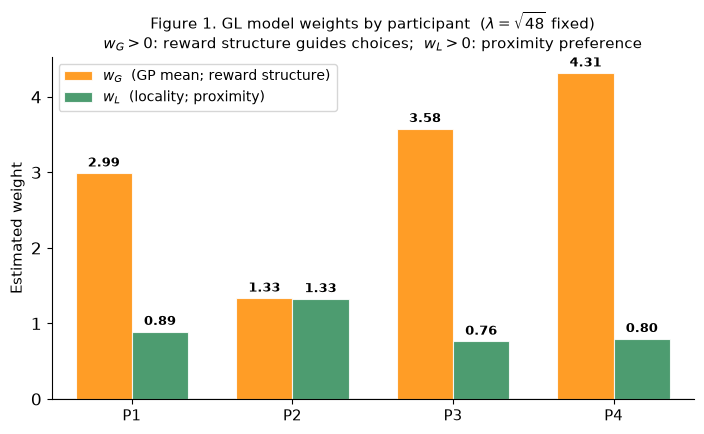

 Participant     w_G     w_L   w_L / w_G
---------------------------------------------
          P1   2.989   0.891        0.30
          P2   1.333   1.325        0.99
          P3   3.577   0.762        0.21
          P4   4.314   0.797        0.18

w_G > 0: GP mean (reward prediction) attracts choices toward expected reward regions.
w_L > 0: proximity preference; nearby blocks are strongly favoured.


In [14]:
# Figure 1: GL model weight estimates per participant (lambda fixed = sqrt(48))
# w_G and w_L shown side-by-side per participant so their relative magnitude is immediately visible.
participants_fig = [p for p, v in gl_fits.items() if v is not None]

w_G_vals = [gl_fits[p]['w_mean']  for p in participants_fig]
w_L_vals = [gl_fits[p]['w_local'] for p in participants_fig]

x = np.arange(len(participants_fig))
width = 0.35

fig, ax = plt.subplots(figsize=(max(6, len(participants_fig) * 1.8), 4.5))

bars_G = ax.bar(x - width / 2, w_G_vals, width, label=r'$w_G$  (GP mean; reward structure)',
                color='darkorange', alpha=0.85, edgecolor='white', linewidth=0.8)
bars_L = ax.bar(x + width / 2, w_L_vals, width, label=r'$w_L$  (locality; proximity)',
                color='seagreen',   alpha=0.85, edgecolor='white', linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.8, zorder=0)

# Value labels on bars
for bars, vals in [(bars_G, w_G_vals), (bars_L, w_L_vals)]:
    for bar, v in zip(bars, vals):
        y_pos = bar.get_height() + 0.05 if v >= 0 else bar.get_height() - 0.15
        va = 'bottom' if v >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f'{v:.2f}',
                ha='center', va=va, fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(participants_fig, fontsize=11)
ax.set_ylabel('Estimated weight', fontsize=11)
ax.set_title(
    r'Figure 1. GL model weights by participant  ($\lambda = \sqrt{48}$ fixed)' + '\n'
    r'$w_G > 0$: reward structure guides choices;  $w_L > 0$: proximity preference',
    fontsize=11
)
ax.legend(fontsize=10, loc='best')
ax.set_xlim(-0.5, len(participants_fig) - 0.5)
plt.tight_layout()
plt.show()

print(f'{"Participant":>12}  {"w_G":>6}  {"w_L":>6}  {"w_L / w_G":>10}')
print('-' * 45)
for p, wg, wl in zip(participants_fig, w_G_vals, w_L_vals):
    ratio = wl / wg if wg != 0 else float('inf')
    print(f'{p:>12}  {wg:>6.3f}  {wl:>6.3f}  {ratio:>10.2f}')
print()
print('w_G > 0: GP mean (reward prediction) attracts choices toward expected reward regions.')
print('w_L > 0: proximity preference; nearby blocks are strongly favoured.')


---
## 6. Model Comparison

### 6.1  Feature ablation: G vs L vs GL

We compare three softmax GLM variants. Wu et al. (2025) fixed $\lambda = \sqrt{48}$ (the ground-truth environment lengthscale), so G and GL each have one fewer parameter than they would with free $\lambda$ estimation:

| Model | Features | Formula | k | $\lambda$ |
|:---:|---|---|:---:|---|
| **L** | Locality only | $\exp(w_L\,\text{loc})$ | 1 | — |
| **G** | GP-mean only | $\exp(w_G\,\mu_t)$ | 1 | fixed $= \sqrt{48}$ |
| **GL** | GP-mean + Locality | $\exp(w_G\,\mu_t + w_L\,\text{loc})$ | 2 | fixed $= \sqrt{48}$ |

BIC = k·ln(n) − 2·ln(L̂); lower is better. L and G both have k=1, so comparing them is a direct test of reward structure vs proximity as the *sole* driver of choices.


In [15]:
# 6.1 Feature ablation: GL (k=2) vs G (k=1) vs L (k=1) — all with fixed lambda = sqrt(48)
participants = [p for p in gl_fits
                if gl_fits[p] is not None
                and g_fits.get(p) is not None
                and l_fits.get(p) is not None]

bic_results = {}
for p in participants:
    n = gl_fits[p]['n_steps']
    bic_gl_p = compute_bic_glm(gl_fits[p]['negloglik'], n_params=2, n_steps=n)
    bic_g_p  = compute_bic_glm(g_fits[p]['negloglik'],  n_params=1, n_steps=n)
    bic_l_p  = compute_bic_glm(l_fits[p]['negloglik'],  n_params=1, n_steps=n)
    best = min(bic_gl_p, bic_g_p, bic_l_p)
    bic_results[p] = {'gl': bic_gl_p, 'g': bic_g_p, 'l': bic_l_p, 'best': best}

print(f'{"Participant":>12}  {"GL (k=2)":>10}  {"G (k=1)":>10}  {"L (k=1)":>10}  {"Winner"}')
print('-' * 56)
for p, b in bic_results.items():
    winners = [m for m in ('gl', 'g', 'l') if b[m] == b['best']]
    print(f'{p:>12}  {b["gl"]:>10.1f}  {b["g"]:>10.1f}  {b["l"]:>10.1f}  '
          f'{" / ".join(w.upper() for w in winners)}')


 Participant    GL (k=2)     G (k=1)     L (k=1)  Winner
--------------------------------------------------------
          P1       605.7      1728.5       651.4  GL
          P2       428.7      1468.3       431.0  GL
          P3       571.5      1309.3       631.9  GL
          P4       528.8      1315.9       608.9  GL


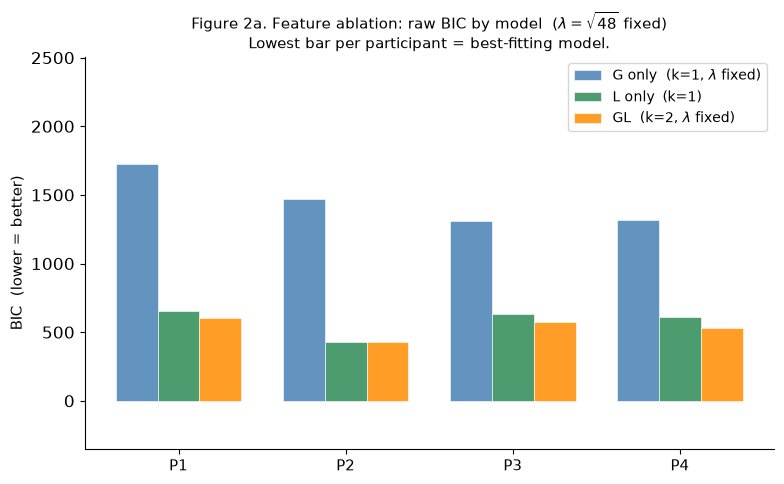

In [16]:
# Figure 2a: raw BIC for feature ablation (lower = better)
if bic_results:
    fig, ax = plt.subplots(figsize=(8, 5))
    x      = np.arange(len(participants))
    width  = 0.25
    models = [
        (r'G only  (k=1, $\lambda$ fixed)', 'g',  'steelblue'),
        (r'L only  (k=1)',                  'l',  'seagreen'),
        (r'GL  (k=2, $\lambda$ fixed)',     'gl', 'darkorange'),
    ]
    for offset, (label, key, col) in enumerate(models):
        vals = [bic_results[p][key] for p in participants]
        ax.bar(x + (offset - 1) * width, vals, width,
               label=label, color=col, alpha=0.85, edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(participants, fontsize=11)
    ax.set_ylabel('BIC  (lower = better)', fontsize=11)
    ax.set_title(
        r'Figure 2a. Feature ablation: raw BIC by model  ($\lambda=\sqrt{48}$ fixed)' + '\n'
        'Lowest bar per participant = best-fitting model.',
        fontsize=11
    )
    ax.legend(fontsize=10)
    all_bic = [bic_results[p][k] for p in participants for k in ('g', 'l', 'gl')]
    margin  = (max(all_bic) - min(all_bic)) * 0.6
    ax.set_ylim(min(all_bic) - margin, max(all_bic) + margin)
    plt.tight_layout()
    plt.show()
else:
    print('Run the BIC cell above to populate bic_results.')


### Interpreting the feature ablation

**GL vs L:** does reward structure (via the GP posterior mean, feature G) improve predictions beyond pure proximity? With $\lambda$ fixed, GL has k=2 vs L's k=1; a lower BIC for GL means the GP mean adds real predictive power.

**GL vs G:** does locality improve predictions beyond reward structure alone? If G wins, participants navigate by the reward map but do not preferentially harvest nearby blocks, which would be surprising given the physical structure of the task.

**G vs L (both k=1):** equal complexity, so this is the cleanest comparison. A lower BIC for G over L means knowing the reward landscape is more predictive than knowing the participant's current position.

### Exercises

**Exercise 1.** Compare $w_L$ across participants. Is it consistently larger than $w_G$? What would this tell you about the relative importance of reward structure vs proximity?

**Exercise 2.** The locality feature uses raw Euclidean distance. Try $\text{loc}(x) = \exp(-\|x - x_\text{curr}\|\,/\,\ell)$ with $\ell = 6.0$. Modify `locality_feature` in [models.py](models.py) and compare BIC.

**Exercise 3.** Try `n_restarts=3` in the fitting loop. Do estimates change? Instability signals a flat or multimodal likelihood surface.


---
### 6.2  Lengthscale sensitivity and the free-$\lambda$ extension

Wu et al. (2025) fixed $\lambda = \sqrt{48}$ to the known environment lengthscale. But how sensitive are results to this choice? We compare GL with $\lambda$ fixed at three values and with $\lambda$ freely estimated (k=3):

| Fit | $\lambda$ | k | Interpretation |
|---|---|:---:|---|
| Fixed $3.0$ | $3.0$ | 2 | Narrow generalization |
| Fixed $\sqrt{48}$ | $\approx 6.93$ | 2 | Paper model; environment ground truth |
| Fixed $14.0$ | $14.0$ | 2 | Broad generalization |
| Free | estimated | 3 | Does estimated $\hat\lambda$ match $\sqrt{48}$? |

Wu et al. (2018) found that people **under-generalize**, with lower estimated $\lambda$ than the ground truth. If fixed $\lambda = 3.0$ beats fixed $\lambda = \sqrt{48}$ by BIC, that prediction is supported here.

**Note:** all four variants below are refit on the same `FIT_SESSION` data as the main GL fits, so BIC values are directly comparable across models.

In [26]:
# 6.2 Lengthscale sensitivity: GL with alternative fixed lambdas and free lambda.
# All four variants are refit on the same FIT_SESSION data so BICs are directly comparable.
sqr48 = np.sqrt(48)
lambda_alts = [3.0, 14.0]
ls_bic = {p: {} for p in participants}

df_sess = df[df['session'] == FIT_SESSION]   # restrict to the same 4 rounds as main fits

for p in participants:
    # Paper model: refit from scratch on the same session data (not reusing precomputed negloglik)
    r48 = fit_participant_glm_no_ucb(df_sess, p, X_all=X_ALL, n_restarts=1,
                                     max_decisions=100, seed=2026,
                                     fixed_lengthscale=sqr48)
    ls_bic[p][sqr48] = compute_bic_glm(r48['negloglik'], n_params=2, n_steps=r48['n_steps'])

    # Fixed alternative lambdas
    for lam in lambda_alts:
        r = fit_participant_glm_no_ucb(df_sess, p, X_all=X_ALL, n_restarts=1,
                                       max_decisions=100, seed=2026,
                                       fixed_lengthscale=lam)
        ls_bic[p][lam] = compute_bic_glm(r['negloglik'], n_params=2, n_steps=r['n_steps'])

    # Free lambda (k=3): allows participant-specific generalization radius
    r_free = fit_participant_glm_no_ucb(df_sess, p, X_all=X_ALL, n_restarts=1,
                                        max_decisions=100, seed=2026)
    ls_bic[p]['free'] = (compute_bic_glm(r_free['negloglik'], n_params=3,
                                         n_steps=r_free['n_steps']),
                         r_free['lengthscale'])

print(f'{"Participant":>12}  {"GL \u03bb=3":>10}  {"GL \u03bb=\u221a48":>10}  {"GL \u03bb=14":>10}  {"GL-free":>10}  {"Est. \u03bb":>8}')
print('-' * 66)
for p in participants:
    b3   = ls_bic[p][3.0]
    b48  = ls_bic[p][sqr48]
    b14  = ls_bic[p][14.0]
    bfr, lam_est = ls_bic[p]['free']
    print(f'{p:>12}  {b3:>10.1f}  {b48:>10.1f}  {b14:>10.1f}  {bfr:>10.1f}  {lam_est:>8.2f}')

print(f'\nsqrt(48) \u2248 {sqr48:.2f}: ground-truth environment lengthscale.')
print(f'Est. \u03bb < {sqr48:.2f} \u2192 under-generalization (Wu et al. 2018 prediction).')
print(f'Est. \u03bb > {sqr48:.2f} \u2192 over-generalization relative to the environment.')

 Participant      GL λ=3    GL λ=√48     GL λ=14     GL-free    Est. λ
------------------------------------------------------------------
          P1       577.6       605.7       637.8       582.3      3.23
          P2       416.7       428.7       435.8       440.7      0.45
          P3       533.2       571.5       617.1       534.7      2.26
          P4       484.5       528.8       590.5       489.4      3.01

sqrt(48) ≈ 6.93: ground-truth environment lengthscale.
Est. λ < 6.93 → under-generalization (Wu et al. 2018 prediction).
Est. λ > 6.93 → over-generalization relative to the environment.


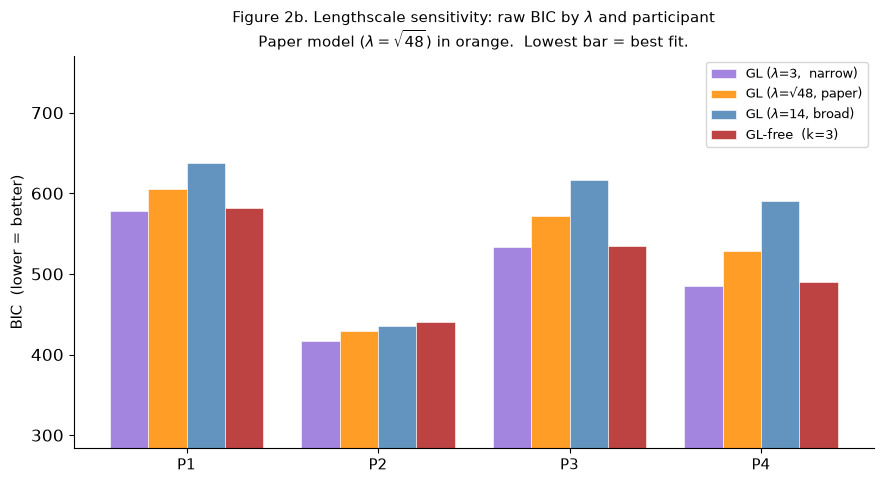

Estimated lambda (GL-free):
  P1: λ̂ = 3.23  (under-gen. vs ground truth)
  P2: λ̂ = 0.45  (under-gen. vs ground truth)
  P3: λ̂ = 2.26  (under-gen. vs ground truth)
  P4: λ̂ = 3.01  (under-gen. vs ground truth)


In [27]:
# Figure 2b: raw BIC for lengthscale variants (lower = better)
if ls_bic:
    sqr48 = np.sqrt(48)
    specs = [
        (r'GL ($\lambda$=3,  narrow)', 3.0,    'mediumpurple'),
        (r'GL ($\lambda$=√48, paper)', sqr48,  'darkorange'),
        (r'GL ($\lambda$=14, broad)',  14.0,   'steelblue'),
        (r'GL-free  (k=3)',            'free', 'firebrick'),
    ]

    fig, ax = plt.subplots(figsize=(9, 5))
    x     = np.arange(len(participants))
    width = 0.2
    for offset, (label, key, col) in enumerate(specs):
        vals = ([ls_bic[p]['free'][0] for p in participants] if key == 'free'
                else [ls_bic[p][key] for p in participants])
        ax.bar(x + (offset - 1.5) * width, vals, width,
               label=label, color=col, alpha=0.85, edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(participants, fontsize=11)
    ax.set_ylabel('BIC  (lower = better)', fontsize=11)
    ax.set_title(
        r'Figure 2b. Lengthscale sensitivity: raw BIC by $\lambda$ and participant' + '\n'
        r'Paper model ($\lambda=\sqrt{48}$) in orange.  Lowest bar = best fit.',
        fontsize=11
    )
    ax.legend(fontsize=9)
    all_vals = ([ls_bic[p]['free'][0] for p in participants] +
                [ls_bic[p][k] for p in participants for k in (3.0, sqr48, 14.0)])
    margin = (max(all_vals) - min(all_vals)) * 0.6
    ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)
    plt.tight_layout()
    plt.show()

    print('Estimated lambda (GL-free):')
    for p in participants:
        _, lam_est = ls_bic[p]['free']
        direction  = 'under-gen.' if lam_est < sqr48 else 'over-gen.'
        print(f'  {p}: λ̂ = {lam_est:.2f}  ({direction} vs ground truth)')
else:
    print('Run the sensitivity cell above first.')


### Interpreting the lengthscale comparison

**If GL(λ=√48) has the lowest BIC**, the paper's ground-truth lengthscale is justified: participants generalize over roughly the right spatial scale.

**If GL(λ=3) wins**, participants under-generalize, with a narrower effective belief radius than the environment warrants, matching the Wu et al. (2018) prediction.

**If GL-free wins** despite the extra BIC penalty for k=3, participants' individual lengthscales differ enough from √48 that the data prefer estimating it. Check whether estimated λ̂ values are consistently shorter or longer than √48.

**Exercise 4.** The free-$\lambda$ fit estimates each participant's effective generalization radius. Is it shorter or longer than $\sqrt{48}$? Does this match the under-generalization prediction from Wu et al. (2018)?

**Exercise 5 (Stretch).** Extension B (GLU) adds $w_U \cdot \sigma_t(x)$. For which participants does it win by BIC? Does positive $w_U$ correlate with the estimated $\hat\lambda$?


---
## Extension A: GL-ARS, Adaptive Locality Weight

The **GL** model treats $w_L$ as fixed throughout a round. The paper's **ARS** model (Area-Restricted Search; Dorfman et al., 2022) replaces it with a dynamic weight:

$$\tilde{w}_L = w_L + \rho\,\Delta t$$

where $\Delta t$ is elapsed time in **seconds** since the last individually-earned reward. We call the resulting model **GL-ARS**. It is still a softmax GLM with the canonical form $P(x) \propto \exp(\mathbf{f}_k \cdot \mathbf{w})$; the only change is that the L-feature weight adapts over time.

| Parameter | Role |
|---|---|
| $w_G$ | GP-mean weight (as in GL; $\lambda = \sqrt{48}$ fixed) |
| $w_L$ | Baseline locality weight at $\Delta t = 0$ (immediately after a reward) |
| $\rho$ | Adaptivity slope: $\rho < 0$ means locality *decreases* as unrewarded time grows |

$\lambda$ is fixed at $\sqrt{48}$ (the paper value), so GL-ARS has k=3 free parameters.

**Biological interpretation:** immediately after a reward, $\tilde{w}_L = w_L$ and a strong bias is placed on searching locally. However, as time passes without reward, $\tilde{w}_L$ decreases and the participant is encouraged to start foraging over longer distances. This is the classic ARS signature.

*Note:* the paper normalises $\Delta t$ before fitting, making $\rho$ directly comparable across participants (and to align with the priors of the Bayesian model). Here, we simply use raw seconds, such that $\rho$ has units of weight/second.

*Note on the visibility feature:* Wu et al. (2025) also used a block-visibility feature. We omit it because the viewing-direction data are not in the simplified dataset.

---

**Exercise:** complete `ars_round_loglik` in the starter code below, fit GL-ARS to P4, and compare its BIC against GL. Does $\rho < 0$ (dispersal) improve fit?

In [19]:
# ── ARS helpers (real time in seconds) ──────────────────────────────────────
def time_since_reward_sec(t_obs, y_obs, t_next):
    """Elapsed time in seconds since the most recent reward, at the moment of decision."""
    reward_times = t_obs[y_obs == 1]
    if len(reward_times) == 0:
        return float(t_next - t_obs[0]) if len(t_obs) > 0 else 0.0
    return float(t_next - reward_times[-1])

def ars_w_local(t_obs, y_obs, t_next, w_local, rho):
    """Time-varying locality weight: w_local_tilde = w_local + rho * Delta_t.
    Negative rho = dispersal as time without reward grows."""
    delta_t = time_since_reward_sec(t_obs, y_obs, t_next)
    return w_local + rho * delta_t

# ── Sanity check: w_local_tilde and step distance across the full round ───────
decisions_timed = list(iter_decisions_with_time(round_df))
W_LOCAL_BASE = 0.5
RHO          = -0.01   # negative: locality decreases as elapsed time without reward grows

print(f'GL-ARS locality weight  (w_L={W_LOCAL_BASE}, rho={RHO}):')
print(f'  {"step":>4}  {"Delta_t (s)":>11}  {"w_L_tilde":>10}  {"dist (blks)":>11}  {"event"}')
print('  ' + '-' * 54)
for step, (X_obs, y_obs, t_obs, next_idx, t_next) in enumerate(decisions_timed):
    delta_t = time_since_reward_sec(t_obs, y_obs, t_next)
    w = ars_w_local(t_obs, y_obs, t_next, W_LOCAL_BASE, RHO)
    if len(X_obs) > 0:
        dist = float(np.linalg.norm(X_ALL[next_idx] - X_obs[-1]))
        dist_str = f'{dist:>11.2f}'
    else:
        dist_str = f'{"—":>11}'
    event = '<-- reward found!' if len(y_obs) > 0 and y_obs[-1] == 1 else ''
    print(f'  {step+1:>4}  {delta_t:>11.1f}  {w:>9.3f}  {dist_str}  {event}')

print()
print('Delta_t is in seconds and resets after a reward to near-zero.')
print('dist (blks): Euclidean distance in raw grid coords (1 unit ≈ 3 blocks) to the next block destruction.')
print('A round lasts 180 seconds, so rho ≈ -0.01 to -0.05 is a reasonable range.')

# ── Extension A skeleton ──────────────────────────────────────────────────────
# Complete this function and write a fitting loop below it.
#
# def ars_round_loglik(decisions_timed, X_all, lengthscale,
#                         w_mean, w_local, rho, noise=0.1):
#     """Paper-model log-likelihood with linear ARS locality weight (Delta_t in seconds)."""
#     total = 0.0
#     for X_obs, y_obs, t_obs, next_idx, t_next in decisions_timed:
#         if len(X_obs) == 0:
#             continue
#         w_local_t = ars_w_local(t_obs, y_obs, t_next, w_local, rho)
#         total += decision_loglik_glm(
#             X_all, X_obs, y_obs, next_idx,
#             lengthscale, w_mean, 0.0, w_local_t, noise
#         )
#     return total
#
# Hint: to fit, minimise neg_loglik over (w_G, w_L, rho) with lambda fixed at sqrt(48).
# Use scipy.optimize.minimize with Nelder-Mead; start rho near 0.
# Use iter_decisions_with_time(round_df) instead of iter_decisions(round_df).
print()
print('Skeleton above. Complete ars_round_loglik, then compare BIC(GL-ARS, k=3) vs BIC(GL, k=2).')


GL-ARS locality weight  (w_L=0.5, rho=-0.01):
  step  Delta_t (s)   w_L_tilde  dist (blks)  event
  ------------------------------------------------------
     1          0.0      0.500            —  
     2          3.8      0.463         3.00  <-- reward found!
     3          7.9      0.420         6.00  
     4         11.1      0.389         3.00  
     5         14.8      0.352         3.00  
     6         20.5      0.295         6.71  
     7         24.4      0.256         3.00  
     8         28.4      0.216         4.24  
     9         33.3      0.167         6.71  
    10         43.8      0.062        24.74  
    11         51.4     -0.014        13.42  
    12         60.0     -0.100        15.30  
    13          3.9      0.461         3.00  <-- reward found!
    14          3.4      0.466         3.00  <-- reward found!
    15          3.5      0.465         3.00  <-- reward found!
    16          3.7      0.463         3.00  <-- reward found!
    17          3.6     

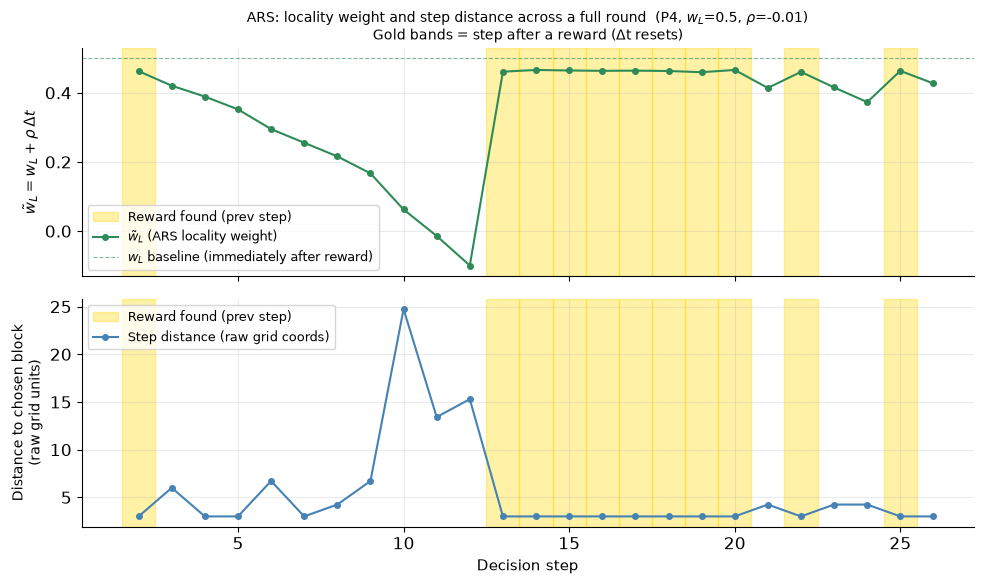

Pearson r(w_L_tilde, step_distance) = -0.807
Negative r expected, since smaller w_L_tilde correlates with longer search distances.


In [28]:
# Figure: w_L_tilde evolution vs actual step distance across the full round
# Prediction: if ARS captures dispersal (rho < 0), w_L_tilde decreases as
# elapsed time grows, and steps should get longer as locality weakens.
steps_plot, wl_vals, dist_vals, reward_steps = [], [], [], []

for step, (X_obs, y_obs, t_obs, next_idx, t_next) in enumerate(decisions_timed):
    if len(X_obs) == 0:
        continue
    w = ars_w_local(t_obs, y_obs, t_next, W_LOCAL_BASE, RHO)
    dist = float(np.linalg.norm(X_ALL[next_idx] - X_obs[-1]))
    steps_plot.append(step + 1)
    wl_vals.append(w)
    dist_vals.append(dist)
    if len(y_obs) > 0 and y_obs[-1] == 1:
        reward_steps.append(step + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax in (ax1, ax2):
    for rs in reward_steps:
        ax.axvspan(rs - 0.5, rs + 0.5, color='gold', alpha=0.35, zorder=0,
                   label='_' if rs != reward_steps[0] else 'Reward found (prev step)')

ax1.plot(steps_plot, wl_vals, color='seagreen', marker='o', markersize=4,
         linewidth=1.5, label=r'$\tilde{w}_L$ (ARS locality weight)')
ax1.axhline(W_LOCAL_BASE, color='seagreen', linewidth=0.8, linestyle='--', alpha=0.6,
            label=r'$w_L$ baseline (immediately after reward)')
ax1.set_ylabel(r'$\tilde{w}_L = w_L + \rho\,\Delta t$', fontsize=11)
ax1.set_title(
    fr'ARS: locality weight and step distance across a full round  ({PARTICIPANT}, '
    fr'$w_L$={W_LOCAL_BASE}, $\rho$={RHO})' + '\nGold bands = step after a reward (Δt resets)',
    fontsize=10
)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

ax2.plot(steps_plot, dist_vals, color='steelblue', marker='o', markersize=4,
         linewidth=1.5, label='Step distance (raw grid coords)')
ax2.set_ylabel('Distance to chosen block\n(raw grid units)', fontsize=10)
ax2.set_xlabel('Decision step', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Correlation: do longer inter-reward intervals actually produce longer steps?
import scipy.stats as st
if len(wl_vals) > 3:
    r, pval = st.pearsonr(wl_vals, dist_vals)
    print(f'Pearson r(w_L_tilde, step_distance) = {r:.3f}')
    print('Negative r expected, since smaller w_L_tilde correlates with longer search distances.')


---
## Extension B: GLU, Adding an Explicit Uncertainty Feature

The **GL** model does not include GP uncertainty $\sigma_t(x)$ as a feature. In Day 1, Block 3, the UCB rule added $\beta\sigma$ to the mean to drive exploration toward uncertain regions. We can test whether participants do the same by adding feature **U** = $\sigma_t(x)$:

$$P(x) \propto \exp\!\bigl(w_G\,\mu_t(x) + w_U\,\sigma_t(x) + w_L\,\text{loc}(x)\bigr)$$

We call this the **GLU** model (k=3: $w_G, w_U, w_L$, with $\lambda = \sqrt{48}$ fixed), and is an extension of GL when $w_U = 0$, GLU reduces to GL.

**Key test:** does $w_U > 0$ with a meaningful BIC gain over GL? A lower BIC for GLU means uncertainty explains additional variance beyond what the GP mean and locality already capture.


In [30]:
# Extension B: GLU (k=3, lambda fixed) vs GL (k=2, lambda fixed)
# Fit GLU using fit_participant_glm with fixed lambda = sqrt(48).
#
# Example:
#   glu_fits[PARTICIPANT] = fit_participant_glm(
#       df, PARTICIPANT, X_all=X_ALL, n_restarts=1,
#       max_decisions=100, seed=2026,
#       fixed_lengthscale=np.sqrt(48))

participants_b = [p for p in glu_fits if glu_fits[p] is not None
                  and gl_fits.get(p) is not None]

if not participants_b:
    print('Run fit_participant_glm (see comment above) to populate glu_fits, then re-run.')
else:
    print(f'{"Participant":>12}  {"GL (k=2)":>10}  {"GLU (k=3)":>10}  {"w_U":>7}  {"Winner"}')
    print('-' * 50)
    for p in participants_b:
        n = gl_fits[p]['n_steps']
        bic_gl  = compute_bic_glm(gl_fits[p]['negloglik'],  n_params=2, n_steps=n)
        bic_glu = compute_bic_glm(glu_fits[p]['negloglik'], n_params=3, n_steps=n)
        winner = 'GL' if bic_gl <= bic_glu else 'GLU'
        w_u = glu_fits[p]['w_ucb']
        print(f'{p:>12}  {bic_gl:>10.1f}  {bic_glu:>10.1f}  {w_u:>7.3f}  {winner}')
    print()
    print('w_U > 0 with GLU winning by a meaningful BIC margin = need to add uncertainty-directed exploration.')
    print('w_U ≈ 0 or GL wins = participants use GP mean (not uncertainty) for exploration.')


Run fit_participant_glm (see comment above) to populate glu_fits, then re-run.


---
## 7. Visualising GL Model Predictions

A quantitative fit is useful, but it is also important to *see* whether the model predictions look sensible qualitatively. We overlay the GL choice probability map on the actual foraging path; the crimson star should fall in a high-probability region if the model is doing its job.

We use the fitted GL parameters for **P4**. We visualise steps 10 and 20 to compare an early decision (GP posterior still forming) with a late decision (well-formed reward map, strong locality signal).

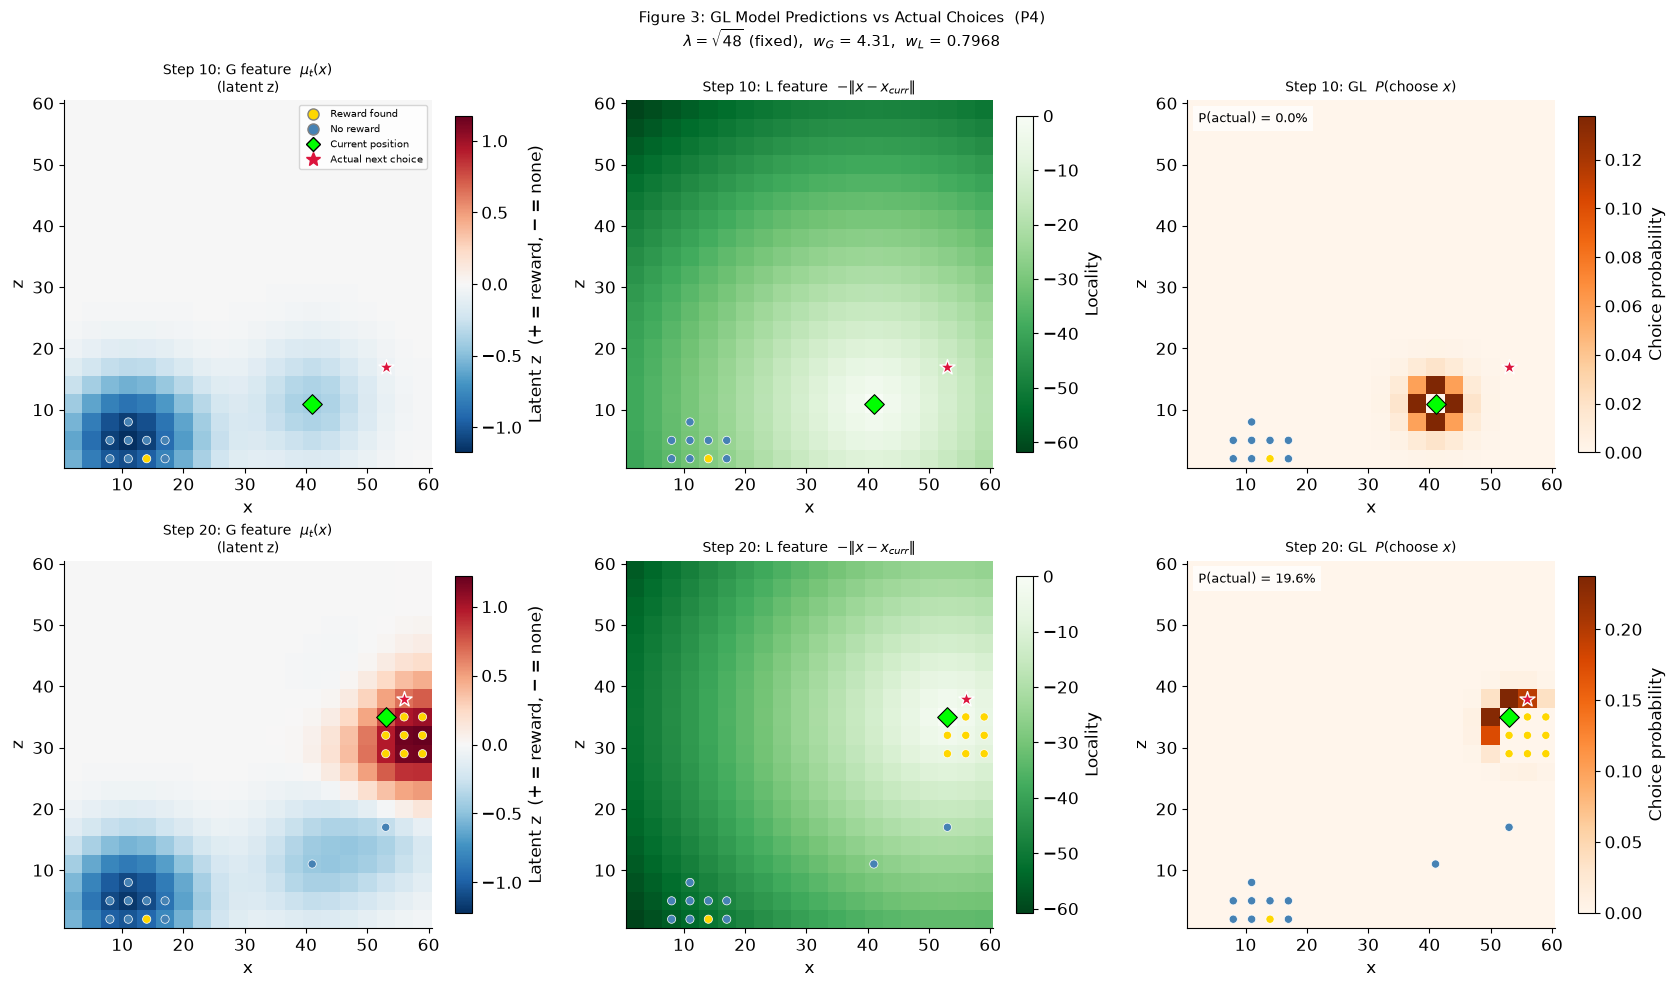

In [22]:
# Figure 3: GL model predictions overlaid on actual choices for the illustrative participant
FIT_P = PARTICIPANT
lam_fit = gl_fits[FIT_P]['lengthscale']
wm_fit  = gl_fits[FIT_P]['w_mean']
wl_fit  = gl_fits[FIT_P]['w_local']

from models import _visited_mask
from matplotlib.lines import Line2D

def scatter_obs(ax, X_obs, y_obs, obs_colors, x_current, next_idx):
    """Overlay past observations, current position, and next choice on ax."""
    if len(X_obs) > 0:
        ax.scatter(X_obs[:, 0], X_obs[:, 1], c=obs_colors, s=35, zorder=3,
                   edgecolors='white', linewidth=0.5)
        ax.scatter(x_current[0], x_current[1], c='lime', s=100, marker='D',
                   zorder=5, edgecolors='black', linewidth=0.8)
    ax.scatter(X_ALL[next_idx, 0], X_ALL[next_idx, 1],
               c='crimson', s=130, marker='*', zorder=6, edgecolors='white')
    ax.set_xlabel('x'); ax.set_ylabel('z')

obs_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',
           markersize=8, markeredgecolor='gray', linewidth=0, label='Reward found'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, markeredgecolor='gray', linewidth=0, label='No reward'),
    Line2D([0], [0], marker='D', color='lime', markersize=7,
           markeredgecolor='black', linewidth=0, label='Current position'),
    Line2D([0], [0], marker='*', color='crimson', markersize=10,
           linewidth=0, label='Actual next choice'),
]

# Use the round selected in Part 1 (already in round_df and decisions)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row_idx, (row_axes, step) in enumerate(zip(axes, [10, 20])):
    if step >= len(decisions):
        step = len(decisions) - 1
    X_obs, y_obs, next_idx = decisions[step]

    if len(X_obs) == 0:
        mu_fit  = np.zeros(N_BLOCKS)
        std_fit = np.ones(N_BLOCKS)
    else:
        mu_fit, std_fit = gp_laplace_posterior(X_obs, y_obs, X_ALL, lengthscale=lam_fit)

    x_current   = X_obs[-1] if len(X_obs) > 0 else None
    loc_fit     = locality_feature(X_ALL, x_current)
    visited_fit = _visited_mask(X_ALL, X_obs)
    probs_fit   = glm_choice_probs(mu_fit, std_fit, loc_fit, wm_fit, 0.0, wl_fit, visited_fit)

    obs_colors = ['gold' if y else 'steelblue' for y in y_obs]
    abs_max    = max(float(np.abs(mu_fit).max()), 1.0)

    # Left: G feature = latent z  (diverging colormap; symmetric around 0)
    ax_mu = row_axes[0]
    im0 = ax_mu.imshow(mu_fit.reshape(N_GRID, N_GRID).T, origin='lower', aspect='equal',
                       cmap='RdBu_r', vmin=-abs_max, vmax=abs_max, extent=GRID_EXTENT)
    scatter_obs(ax_mu, X_obs, y_obs, obs_colors, x_current, next_idx)
    ax_mu.set_title(f'Step {step}: G feature  $\\mu_t(x)$\n(latent z)', fontsize=10)
    plt.colorbar(im0, ax=ax_mu, shrink=0.85, label='Latent z  (+ = reward, − = none)')
    if row_idx == 0:
        ax_mu.legend(handles=obs_legend, fontsize=7, loc='upper right')

    # Middle: locality
    ax_loc = row_axes[1]
    im1 = ax_loc.imshow(loc_fit.reshape(N_GRID, N_GRID).T, origin='lower', aspect='equal',
                        cmap='Greens_r', extent=GRID_EXTENT)
    scatter_obs(ax_loc, X_obs, y_obs, obs_colors, x_current, next_idx)
    ax_loc.set_title(f'Step {step}: L feature  $-\\|x - x_{{curr}}\\|$', fontsize=10)
    plt.colorbar(im1, ax=ax_loc, shrink=0.85, label='Locality')

    # Right: GL choice probabilities
    ax_prob = row_axes[2]
    im2 = ax_prob.imshow(probs_fit.reshape(N_GRID, N_GRID).T, origin='lower', aspect='equal',
                         cmap='Oranges', extent=GRID_EXTENT)
    scatter_obs(ax_prob, X_obs, y_obs, obs_colors, x_current, next_idx)
    p_actual = probs_fit[next_idx]
    ax_prob.set_title(f'Step {step}: GL  $P(\\text{{choose }}x)$', fontsize=10)
    plt.colorbar(im2, ax=ax_prob, shrink=0.85, label='Choice probability')
    ax_prob.text(0.03, 0.97, f'P(actual) = {p_actual*100:.1f}%',
                 transform=ax_prob.transAxes, fontsize=9, va='top',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

fig.suptitle(
    f'Figure 3: GL Model Predictions vs Actual Choices  ({FIT_P})\n'
    rf'$\lambda = \sqrt{{48}}$ (fixed),  $w_G$ = {wm_fit:.2f},  $w_L$ = {wl_fit:.4f}',
    fontsize=11
)
plt.tight_layout()
plt.show()


---
## Summary

### What we did

| Part | Content |
|---|---|
| **1** | Loaded data and plotted an illustrative round  |
| **2** | Visualised GP posterior evolution using the Laplace approximation, which maps binary rewards to a latent z |
| **3** | Introduced the **softmax GLM** from Wu et al. (2025): $P(\text{Choice}_{k+1}) \propto \exp(\mathbf{f}_k \cdot \mathbf{w})$; defined features G, L, U and named models by letter codes |
| **4** | Fitted **GL** (k=2, $\lambda$ fixed) and ablations **G** (k=1) and **L** (k=1) by MLE (scipy Nelder-Mead) |
| **5** | Compared fitted weights $w_G$ and $w_L$ across all four participants |
| **6** | Three-way $\Delta$BIC comparison (GL vs G vs L) + lengthscale sensitivity (fixed vs free $\lambda$) |
| **7** | Qualitative validation: GL predictions overlaid on actual foraging paths |
| **Ext. A** | **GL-ARS**: adaptive locality weight $\tilde{w}_L = w_L + \rho\,\Delta t$ (Area-Restricted Search; k=3) |
| **Ext. B** | **GLU**: adds explicit uncertainty weight $w_U\,\sigma_t(x)$ to GL (k=3); tests directed exploration |

### Key changes from Day 1, Block 3

| Change | Why it matters |
|---|---|
| **UCB+softmax → softmax GLM** | The GLM framework makes it straightforward to add, remove, and compare features; both Block 3 UCB and today's GLU are instances of the same canonical form $\exp(\mathbf{f}\cdot\mathbf{w})$ |
| **Locality feature (L) added** | Participants move physically through the environment; locality preference must be separated from reward structure to avoid confounding |
| **GP regression → GP classification (Laplace)** | Binary 0/1 rewards require a Bernoulli likelihood; the Laplace approximation allows for inferring a latent z |
| **$\lambda$ fixed at $\sqrt{48}$** | Wu et al. (2025) assumed the known environment lengthscale; this means G and L each have a single parameter, while GL has two |
| **Destroyed blocks excluded** | Blocks can only be destroyed once; the choice distribution must be over a changing set of undestroyed blocks |
| **MLE instead of STAN** | STAN gives posteriors and hierarchical pooling, but requires significant compute and time; MLE is sufficient for learning the basics |

### Key findings

1. **GL beats both G and L by BIC**: both reward structure (G) and proximity (L) contribute independently, with neither alone explaining choices.
2. **Reward structure and proximity both positive**: $w_G > 0$ and $w_L > 0$ for all participants, confirming that the GP posterior mean guides choices toward expected rewards while proximity preference keeps search locally clustered.
3. **Lengthscale sensitivity**: the free-$\lambda$ extension (k=3) reveals whether participants' effective generalization radius matches $\sqrt{48}$; the under-generalization prediction from Wu et al. (2018) expects estimated $\hat{\lambda} < \sqrt{48}$.

### Connection to Wu et al. (2025)

The 2025 paper extended the asocial GL model to social learning by adding features for others' observed positions and whether they were also observed successfully finding rewards. The ARS model (Extension A) is the same baseline against which social learning effects were measured. The paper's best model (ARS+Conditional learner) builds on the same softmax GLM canonical form, with dynamic weights driving by both an individual locality bias and selective social learning propensity.

### Further reading

Dorfman, A., Hills, T. T., & Scharf, I. (2022). A guide to area‐restricted search: a foundational foraging behaviour. Biological Reviews, 97(6), 2076-2089. https://doi.org/10.1111/brv.12883 

Rasmussen, C. E., & Williams, C. K. I. (2005). *Gaussian Processes for Machine Learning*. MIT Press. https://doi.org/10.7551/mitpress/3206.001.0001

Wilson, R. C., & Collins, A. G. (2019). Ten simple rules for the computational modeling of behavioral data. *eLife*, 8, e49547. https://doi.org/10.7554/eLife.49547

Wu, C. M., Schulz, E., Speekenbrink, M., Nelson, J. D., & Meder, B. (2018). Generalization guides human exploration in vast decision spaces. *Nature Human Behaviour*, 2, 915–924. https://doi.org/10.1038/s41562-018-0467-4

Wu, C. M., Deffner, D., Kahl, B., Meder, B., Ho, M. K., & Kurvers, R. H. J. M. (2025). Adaptive mechanisms of social and asocial learning in immersive foraging environments. *Nature Communications*, 16, 3539. https://doi.org/10.1038/s41467-025-58365-6
